https://stat.ethz.ch/CRAN/web/packages/Rprofet/vignettes/Rprofet.html?utm_source=chatgpt.com#

**Objective** The purpose of this project is to develop an interpretable Probability of Default model and credit scorecard using LendingClub data. The model is designed to rank borrowers by credit risk and estimate the probability that a loan will default. Logistic regression with Weight of Evidence transformation is used as the primary scorecard model, while XGBoost is evaluated as a nonlinear challenger.

- 1=Default/Charged Off
- 0=Fully Paid/Non-default

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import brier_score_loss
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
    roc_auc_score,brier_score_loss,log_loss,confusion_matrix,classification_report)
from xgboost import XGBClassifier

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
file_path = "/content/drive/MyDrive/credit risk-lending clubb/loan_data_2007_2014.csv"
df = pd.read_csv(file_path).set_index('Unnamed: 0')
display(df.head())
print("data shape", df.shape)
display(df.info())
display(df.describe())
isna_sum_df = pd.DataFrame(round((df.isnull().sum()/df.shape[0] * 100), 3), columns = ['Sum_na'])
columns_100_na = isna_sum_df[isna_sum_df['Sum_na'] == 100].index

# cleaning delete columns with 100% null
df.drop(columns_100_na, axis = 1, inplace = True)

# columns with std = 0
std_0_columns = 'policy_code'
df.drop(std_0_columns, axis = 1, inplace = True)

df = df.sort_values(by = 'issue_d')

nan_null = df[~df.isna()]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


data shape (466285, 74)
<class 'pandas.core.frame.DataFrame'>
Index: 466285 entries, 0 to 466284
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           466285 non-null  int64  
 1   member_id                    466285 non-null  int64  
 2   loan_amnt                    466285 non-null  int64  
 3   funded_amnt                  466285 non-null  int64  
 4   funded_amnt_inv              466285 non-null  float64
 5   term                         466285 non-null  object 
 6   int_rate                     466285 non-null  float64
 7   installment                  466285 non-null  float64
 8   grade                        466285 non-null  object 
 9   sub_grade                    466285 non-null  object 
 10  emp_title                    438697 non-null  object 
 11  emp_length                   445277 non-null  object 
 12  home_ownership               466285 non

None

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,466256.000000,466256.000000,215934.000000,62638.000000,466256.000000,466256.000000,4.662850e+05,465945.000000,466256.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466140.000000,98974.000000,466285.0,0.0,0.0,0.0,466256.000000,3.960090e+05,3.960090e+05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,0.284678,0.804745,34.104430,74.306012,11.187069,0.160564,1.623020e+04,56.176947,25.064430,4410.062342,4408.452258,11540.686220,11469.892747,8866.014657,2588.677225,0.650129,85.344211,8.961534,3123.913796,0.009085,42.852547,1.0,NaN,NaN,NaN,0.004002,1.919135e+02,1.388017e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,0.797365,1.091598,21.778487,30.357653,4.987526,0.510863,2.067625e+04,23.732628,11.600141,6355.078769,6353.198001,8265.627112,8254.157579,7031.687997,2483.809661,5.265730,552.216084,85.491437,5554.737393,0.108648,21.662591,0.0,NaN,NaN,NaN,0.068637,1.463021e+04,1.521147e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,0.000000,0.000000,16.000000,53.000000,8.000000,0.000000,6.413000e+03,39.200000,17.000000,0.000000,0.000000,5552.125349,5499.250000,3708.560000,957.280000,0.000000,0.000000,0.000000,312.620000,0.000000,26.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,2.861800e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,0.000000,0.000000,31.000000,76.000000,10.000000,0.000000,1.176400e+04,57.600000,23.000000,441.470000,441.380000,9419.250943,9355.430000,6817.760000,1818.880000,0.000000,0.000000,0.000000,545.960000,0.000000,42.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,8.153900e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,0.000000,1.000000,49.000000,102.000000,14.000000,0.000000,2.033300e+04,74.700000,32.000000,7341.650000,7338.390000,15308.158460,15231.310000,12000.000000,3304.530000,0.000000,0.000000,0.000000,3187.510000,0.000000,59.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,2.089530e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,

The dataset contains borrower characteristics, loan terms, credit-history measures, LendingClub risk grades, and post-origination loan-performance information. Because the objective is to estimate default risk at origination, only information available at or before loan issuance should be eligible for modeling.

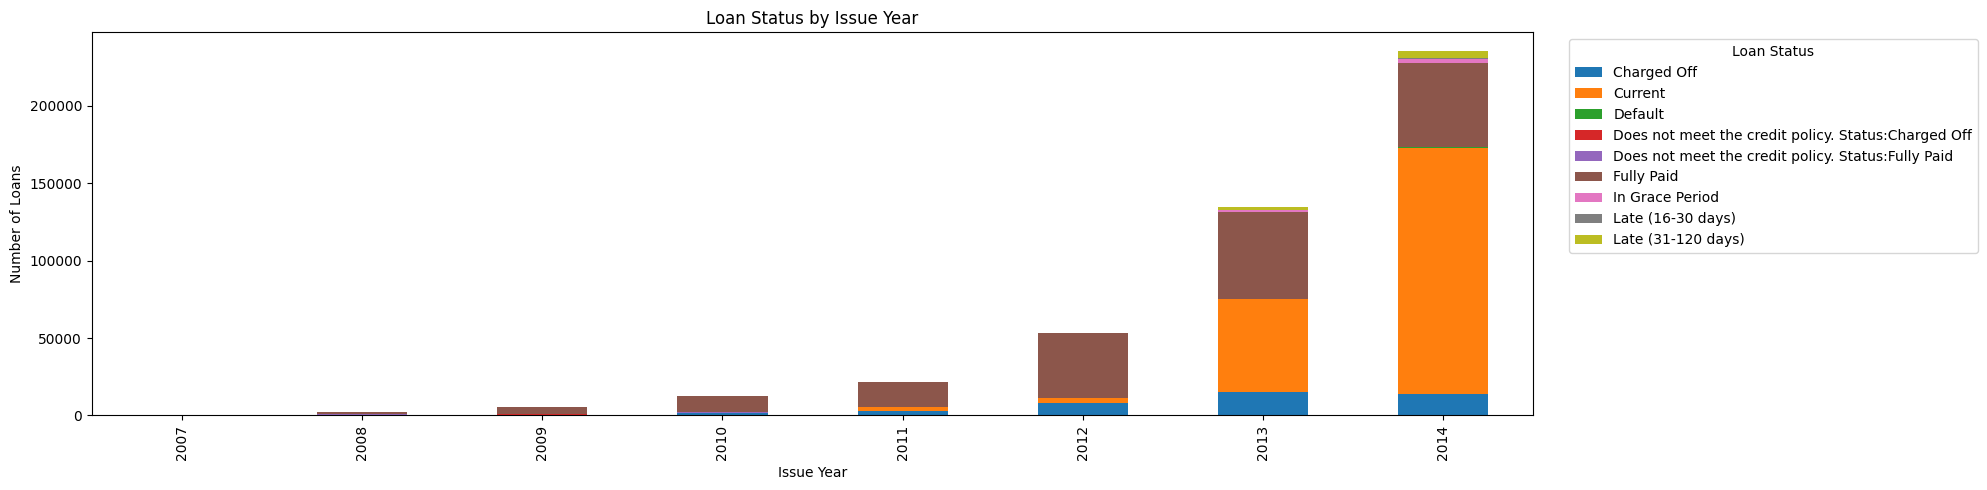

In [3]:
# sort data based on the issue_date
# issue_year
df['issue_y'] = pd.to_datetime(df['issue_d'], format='%b-%y').dt.year
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%y')
df = df.sort_values(by = 'issue_d')
loan_status_by_year = pd.crosstab(df['issue_y'], df['loan_status'])

ax = loan_status_by_year.plot(kind="bar",stacked=True,figsize=(20, 5))
ax.set_title("Loan Status by Issue Year")
ax.set_xlabel("Issue Year")
ax.set_ylabel("Number of Loans")
ax.legend(title="Loan Status",bbox_to_anchor=(1.02, 1),loc="upper left")

plt.tight_layout()
plt.show()

In [4]:
nan_null[nan_null['loan_status'] == 'Current'].head(1)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
17713,712132,905184,20000,20000,14799.99537,60 months,16.02,486.58,D,D5,The Culture Project,< 1 year,RENT,52000.0,Verified,Apr-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 03/25/11 > I will be using...,debt_consolidation,Vanessa,112xx,NY,17.24,2.0,Dec-96,1.0,18.0,NaN,8.0,0.0,19519,75.1,25.0,f,1464.22,1094.52,27656.14,20445.43,18535.75,9120.39,0.0,0.0,0.0,Jan-16,486.58,Feb-16,Jan-16,0.0,NaN,INDIVIDUAL,0.0,NaN,NaN,NaN


This customer has loan ID **1,075,358** and member ID **1,311,748**; these are simply identifiers and do not describe credit risk. The borrower requested a **3,000 loan (`loan_amnt`)**, the full 3,000 was funded (`funded_amnt`), and investors funded the entire 3,000 (`funded_amnt_inv`). The loan term is **60 months**, the annual interest rate is **12.69%**, and the scheduled monthly installment is **67.79**. LendingClub assigned the loan **Grade B, Sub-grade B5**, representing the lender’s assessment of the borrower’s credit quality and corresponding pricing. The borrower reported working for **University Medical Group** for **1 year**, rents their home (`RENT`), and reported **$80,000 annual income**. `Source Verified` means LendingClub verified the source of the reported income. The loan was issued in **December 2011** and its status at the time of this dataset snapshot was **Current**, meaning it was still active and had not yet reached a final outcome such as Fully Paid or Charged Off. `pymnt_plan = n` means the borrower was not on a special payment plan. The `url` identifies the LendingClub loan page, while `desc` contains the borrower’s written description of why the money was needed. The official loan purpose was classified as **Other**, with the borrower-provided title **Personal**. The borrower lived in ZIP code **972xx, Oregon**.

Regarding the borrower’s credit history, `dti = 17.94` means their monthly debt obligations represented approximately **17.94% of monthly income**, according to LendingClub's DTI definition. `delinq_2yrs = 0` means there were **no 30+ day delinquencies during the previous two years**. The earliest reported credit account was opened in **January 1996 (`earliest_cr_line`)**, meaning the borrower had a relatively long credit history by the time the loan was issued in 2011. `inq_last_6mths = 0` means there were **no qualifying credit inquiries during the previous six months**. `mths_since_last_delinq = 38` means the borrower had experienced a delinquency in the past, but the most recent one was about **38 months earlier**, which explains why `delinq_2yrs` can still equal zero: 38 months is outside the most recent 24-month period. `mths_since_last_record = NaN`, together with `pub_rec = 0`, is consistent with there being **no recorded public-record event from which to calculate the number of months**, although missing-data availability should still be considered. The borrower had **15 open credit accounts (`open_acc`)**, no public records (`pub_rec = 0`), and **38 total credit accounts (`total_acc`)** over their credit history. `revol_bal = 27,783` means the borrower currently owed a total of **$27,783 across revolving credit accounts**, such as credit cards and revolving lines of credit. `revol_util = 53.9%` means the borrower was using **53.9% of the total revolving credit available to them**; for example, if someone had about 50,000 of revolving limits and owed about 27,000, their utilization would be around this level. It does **not** mean the borrower owes 27,783 on this LendingClub loan—the LendingClub loan itself is only 3,000. `initial_list_status = f` describes how the loan was initially listed on LendingClub and is an administrative/investment-platform field rather than a borrower financial characteristic.

For the performance of this particular 3,000 loan, `out_prncp = 766.90` means **766.90 of principal was still outstanding**, and `out_prncp_inv = 766.90` is the corresponding outstanding principal attributable to investors. The borrower had paid a total of **3,242.17 (`total_pymnt`)**, and investors had received the same **3,242.17 (`total_pymnt_inv`)**. Of those payments, **2,233.10 was principal (`total_rec_prncp`)** and **1,009.07 was interest (`total_rec_int`)**. Notice that 2,233.10 of principal repaid plus 766.90 outstanding equals the original 3,000 principal. `total_rec_late_fee = 0` means no late-payment fees had been collected. `recoveries = 0` means LendingClub had not recovered money after a charge-off, which is expected because this loan was still Current, and `collection_recovery_fee = 0` means there were no associated recovery collection fees. The most recent payment was in **January 2016 (`last_pymnt_d`)**, and that payment was **67.79 (`last_pymnt_amnt`)**, equal to the scheduled installment. The next scheduled payment was **February 2016 (`next_pymnt_d`)**, confirming that the loan was still active. The latest credit-report pull occurred in **January 2016 (`last_credit_pull_d`)**. `collections_12_mths_ex_med = 0` means there were no non-medical collections reported during the previous 12 months. `mths_since_last_major_derog = NaN` means there is no reported number of months since a major derogatory event; this may indicate no such event or unavailable historical information. `application_type = INDIVIDUAL` means this was an individual rather than joint application. `acc_now_delinq = 0` means **none of the borrower’s accounts were currently delinquent**. Finally, `tot_coll_amt`, `tot_cur_bal`, and `total_rev_hi_lim` are all `NaN`. `tot_coll_amt` would represent total collection amounts, `tot_cur_bal` would represent the total current balance across credit accounts, and `total_rev_hi_lim` would represent the total revolving credit limit; for this older 2011 loan these fields were not available in the dataset, so **NaN should be interpreted as unavailable information, not as zero**.

Overall, this is an **active borrower who had no recent delinquencies, no current delinquent accounts, no public records, no recent inquiries, and no recent collections, although they had experienced a delinquency approximately 38 months earlier. They were using 53.9% of their available revolving credit and still owed 766.90 on the LendingClub loan at the observation date.** Because the loan was still `Current`, you do not yet know whether it will ultimately become **Fully Paid or Default/Charged Off**, which is why this borrower belongs in the data you want your trained PD model to score.


Post-origination leakage control. Variables describing subsequent loan performance were excluded because they would not have been known at the time of the credit decision. Including fields such as outstanding principal, payments received, recoveries, or last-payment information would allow the model to infer the outcome using future information and would produce unrealistically optimistic performance.

In [5]:
# drop columns lead data leakage, tell about future payment: Information available when loan is issued
leakage_cols = ['out_prncp','out_prncp_inv','total_pymnt',
    'total_pymnt_inv','total_rec_prncp','total_rec_int',
    'total_rec_late_fee','recoveries','collection_recovery_fee',
    'last_pymnt_d','last_pymnt_amnt','next_pymnt_d','last_credit_pull_d']

df.drop(columns=leakage_cols, inplace=True)
print('#'*100)
print("data shape after drop columns 100% na and std = 0, data leakage ", df.shape)

####################################################################################################
data shape after drop columns 100% na and std = 0, data leakage  (466285, 44)


Missing values in credit-event recency variables were treated as potentially informative rather than automatically replaced with zero. A value of zero indicates a very recent event, whereas a missing value may indicate that no qualifying event is recorded. Missing indicators were therefore created and the corresponding continuous variable was imputed beyond its observed maximum so that these cases remained distinguishable.

In [6]:
# cleaning phase two

# columns to drop
# id :  A unique LC assigned ID for the loan listing.
# member_id: A unique LC assigned Id for the borrower member.
# emp_title : 205475 unique values + 27588 nan values
# pymnt_plan : only 9 observation == y , drop low std
# url : 466285  unique value
# desc : 124435  unique values
# title : stated by the lender , the purpose of the loan 63098  unique value
# application_type: 466285  unique value

column_to_drop = ['id', 'member_id', 'emp_title', 'pymnt_plan', 'url', 'desc', 'title', 'application_type']
df.drop(column_to_drop, axis = 1, inplace = True)
df.shape

# nan value
# emp_length nan value replace with unemployes
df['emp_length'].fillna('Missing', inplace = True)
# drop rows with annual_inc == nan , only 4 rows , do not replace with 0 become outliers
df.dropna(subset = ['annual_inc'], inplace = True)


# df[(df['mths_since_last_delinq'].isna()) & (df['delinq_2yrs']==0)].shape is  249826 which means in the past 2 years no deliquncy, if replace nan
# values in mths_since_last_delinq with 0 means now the lender delinquence
# create new column
df['no_recorded_delinq'] = df['mths_since_last_delinq'].isna().astype(int)
df['mths_since_last_delinq_imp'] = (df['mths_since_last_delinq'].fillna(df['mths_since_last_delinq'].max() + 1))
df.drop('mths_since_last_delinq', axis = 1, inplace = True)

# mths_since_last_record means the number of months since the borrower’s most recent public record appeared on their credit file.
# mths_since_last_record = 0, it means the borrower’s most recent public record occurred within the current month or less than one month ago
df['no_record'] = df['mths_since_last_record'].isna().astype(int)
df['mths_since_last_record_imp'] = (df['mths_since_last_record'].fillna(df['mths_since_last_record'].max() + 1))
df.drop('mths_since_last_record', axis=1, inplace=True)

# mths_since_last_major_derog: The number of months since the borrower’s most recent major derogatory credit event.
df['no_major_derog'] = df['mths_since_last_major_derog'].isna().astype(int)
df['mths_since_last_major_derog_imp'] = (df['mths_since_last_major_derog'].fillna(df['mths_since_last_major_derog'].max() + 1))
df.drop('mths_since_last_major_derog', axis=1, inplace=True)

# categorical columns
df['term'] = np.where(df['term'] == ' 36 months', 1, 0)
df['home_ownership'] = np.where(df['home_ownership'].isin(['OTHER', 'NONE', 'ANY']), 'OTHER_NONE_ANY', df['home_ownership'])

# date time columns
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y')
mask = df['earliest_cr_line'] > df['issue_d']

df.loc[mask, 'earliest_cr_line'] = (df.loc[mask, 'earliest_cr_line'] - pd.DateOffset(years=100))

df['credit_history_months'] = ((df['issue_d'].dt.year - df['earliest_cr_line'].dt.year) * 12
    + (df['issue_d'].dt.month - df['earliest_cr_line'].dt.month))
df.drop(['earliest_cr_line'], axis=1, inplace=True)

The original earliest-credit-line date was converted into credit_history_months, defined as the number of months between the borrower's earliest recorded credit account and the loan issue date. This produces a directly interpretable measure of credit-history length while avoiding the use of raw calendar dates as predictors.

##################### Numerical Variables #####################


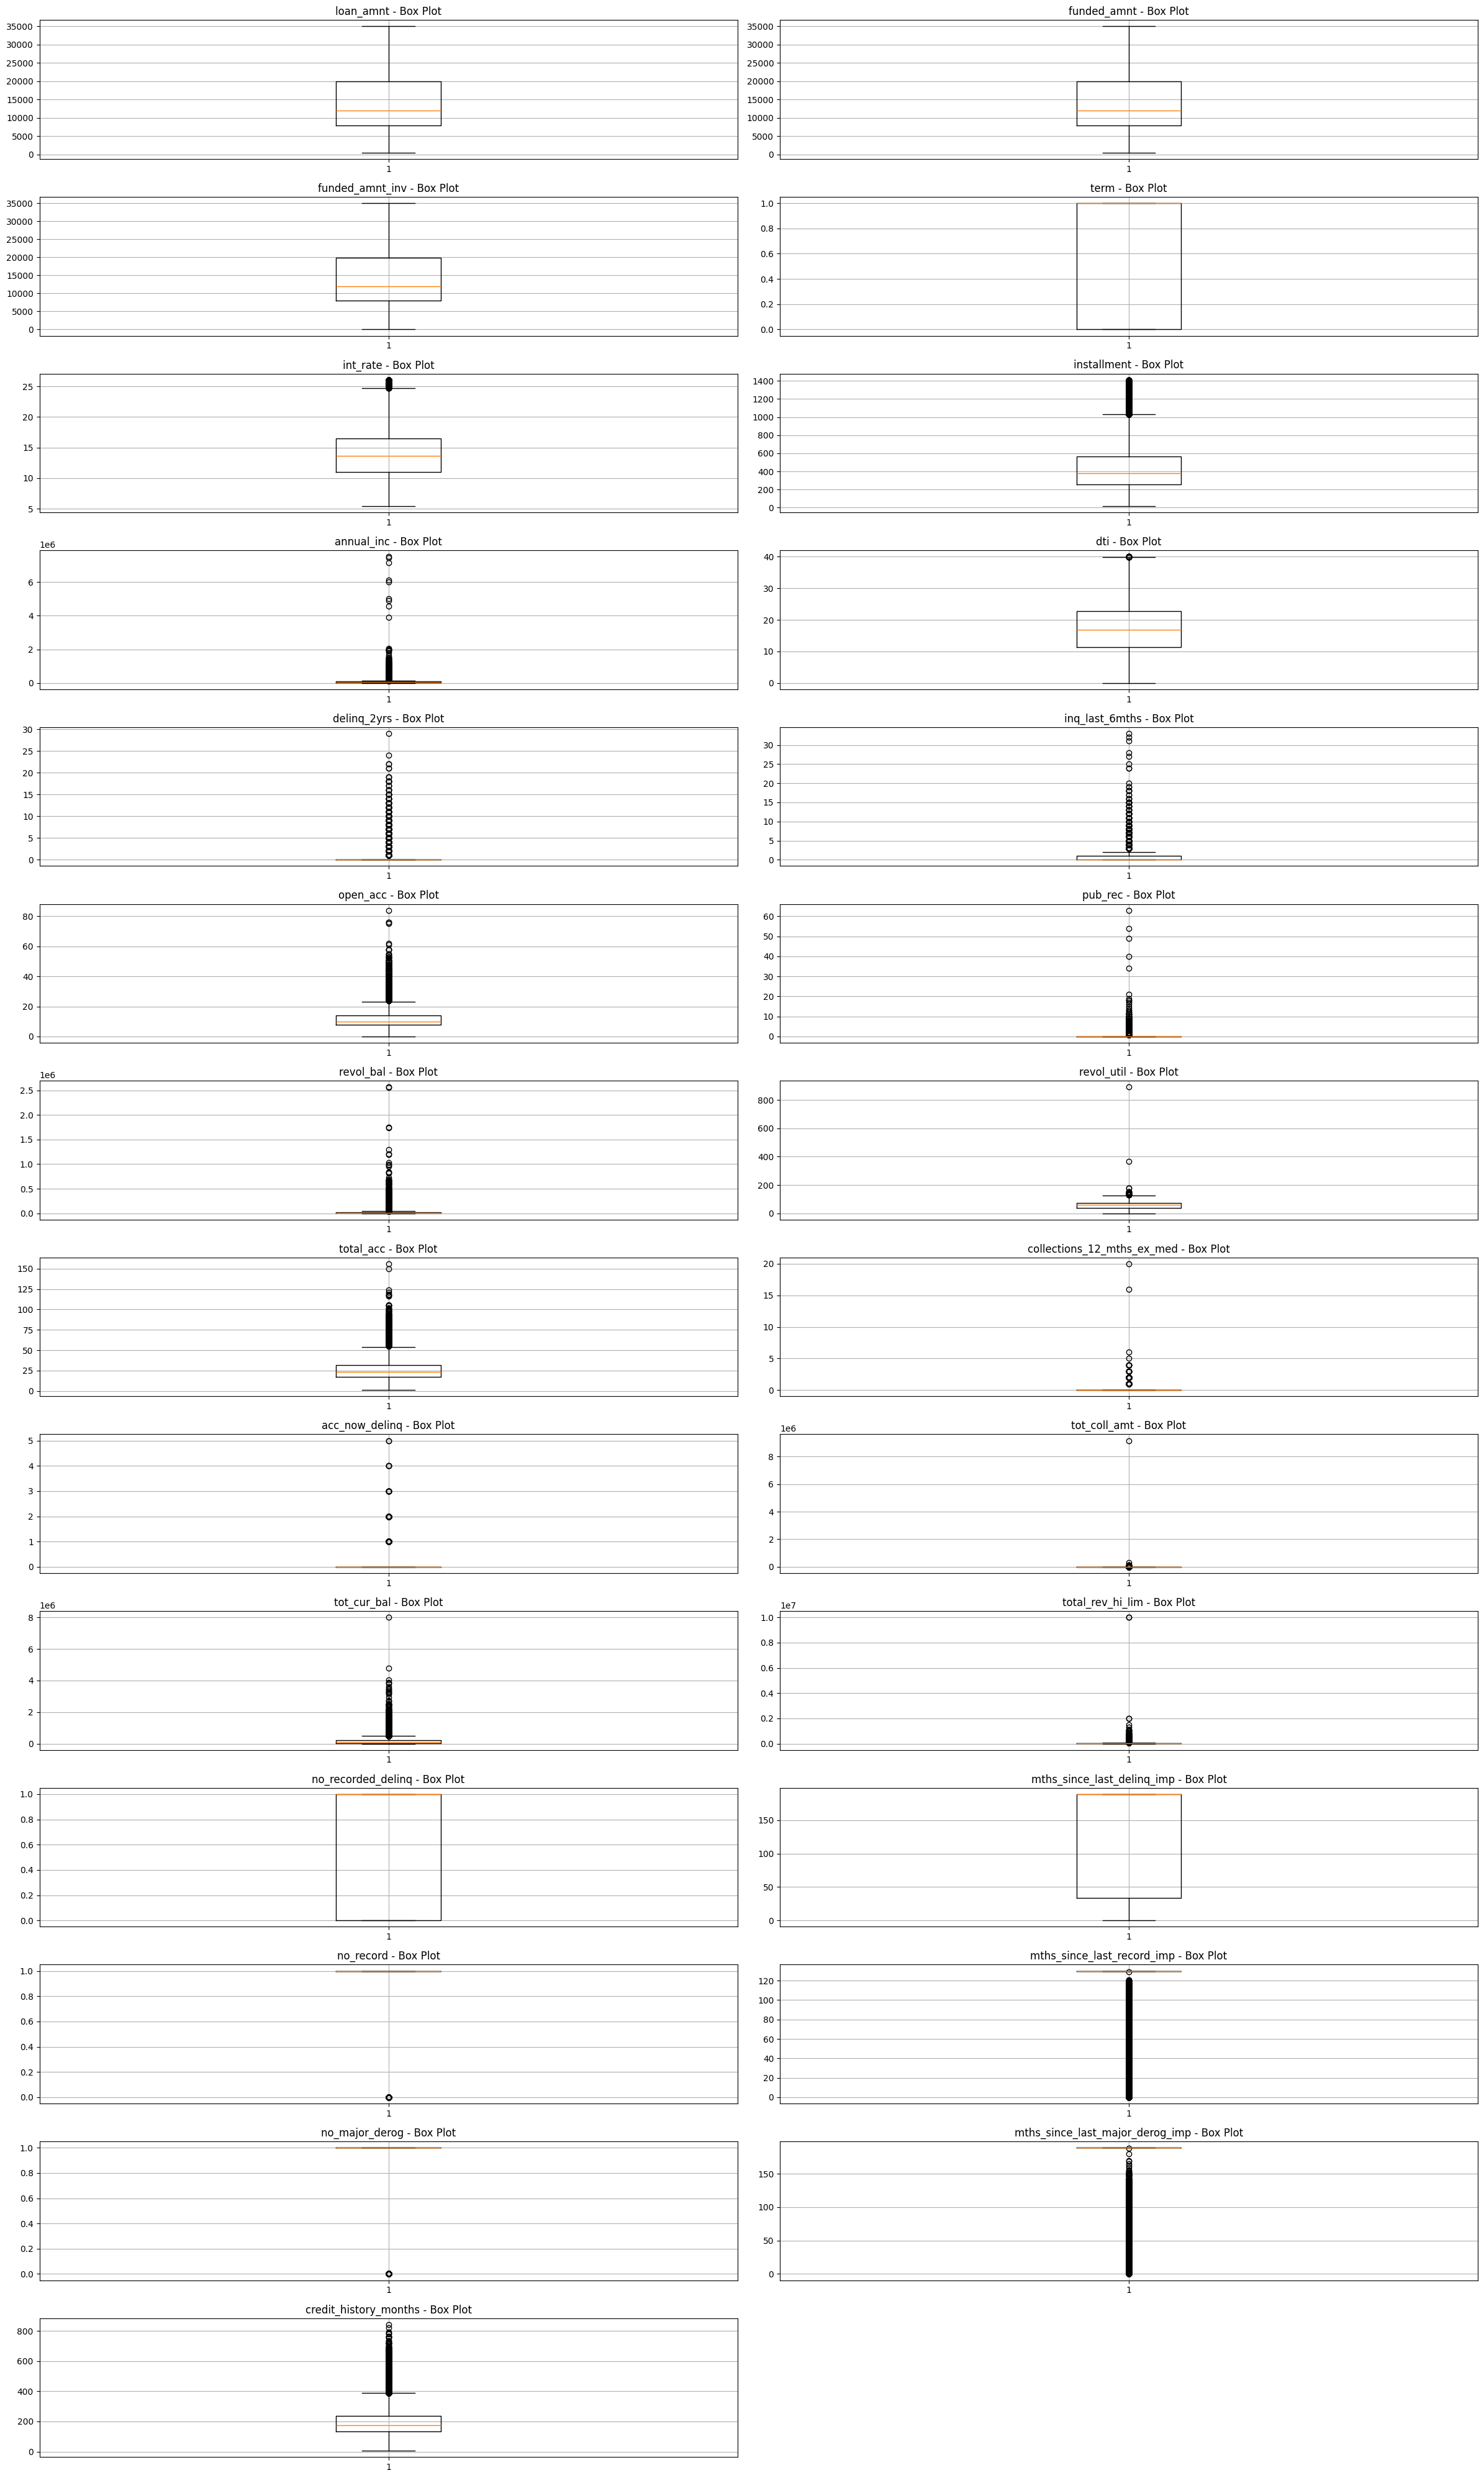

None

##################### Categorical Variables #####################


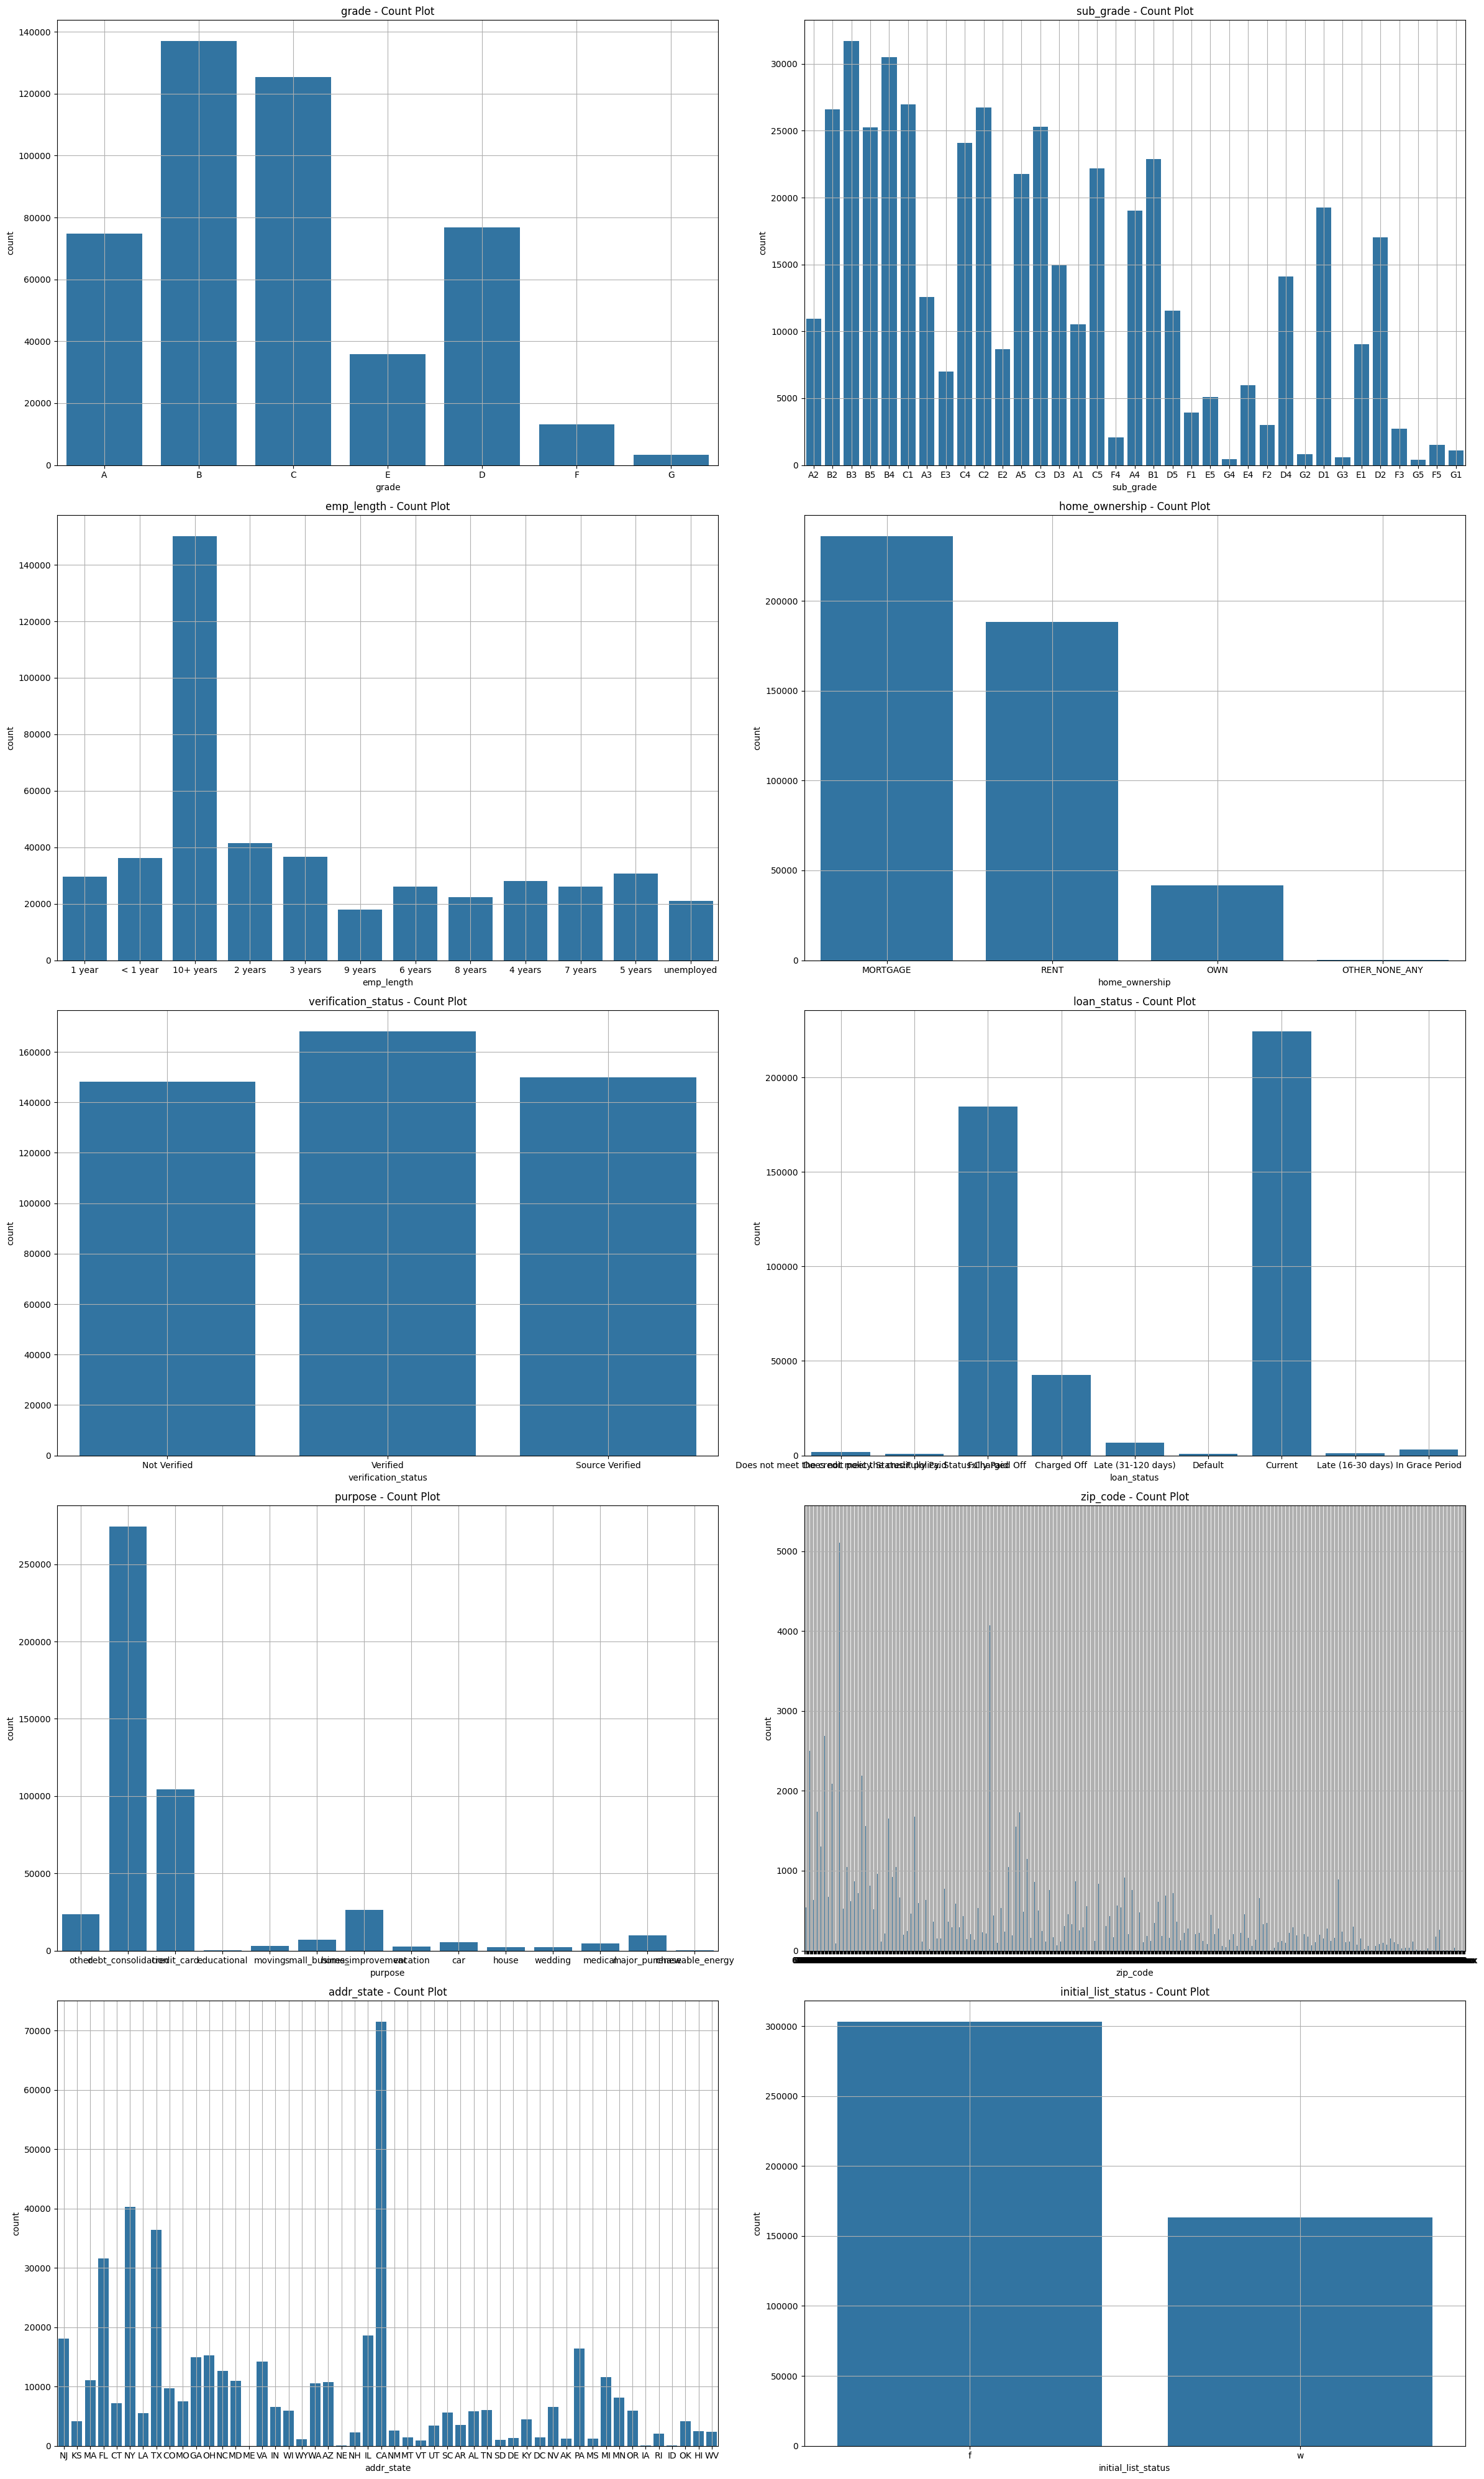

None

In [7]:
num_df = df.select_dtypes(include = ['int64', 'float64'])
cat_df = df.select_dtypes(include = ['object'])
cat_df['loan_status'] = df['loan_status']
print('##################### Numerical Variables #####################')
fig, axes = plt.subplots(nrows=14,ncols=2,figsize=(24, 40))
for i, col in enumerate(num_df.columns):
    row = i // 2
    col_pos = i % 2
    # Box plot
    axes[row, col_pos].boxplot(num_df[col].dropna())
    axes[row, col_pos].set_title(f"{col} - Box Plot")
    axes[row, col_pos].grid(True)
fig.delaxes(axes[-1, -1])
plt.tight_layout()

display(plt.show())

print('##################### Categorical Variables #####################')
fig, axes = plt.subplots(nrows=5,ncols=2,figsize=(24, 40))
for i, col in enumerate(cat_df.columns):
    row = i // 2
    col_pos = i % 2
    # Box plot
    sns.countplot(cat_df, x = col,ax = axes[row, col_pos])
    axes[row, col_pos].set_title(f"{col} - Count Plot")
    axes[row, col_pos].grid(True)

plt.tight_layout()

display(plt.show())

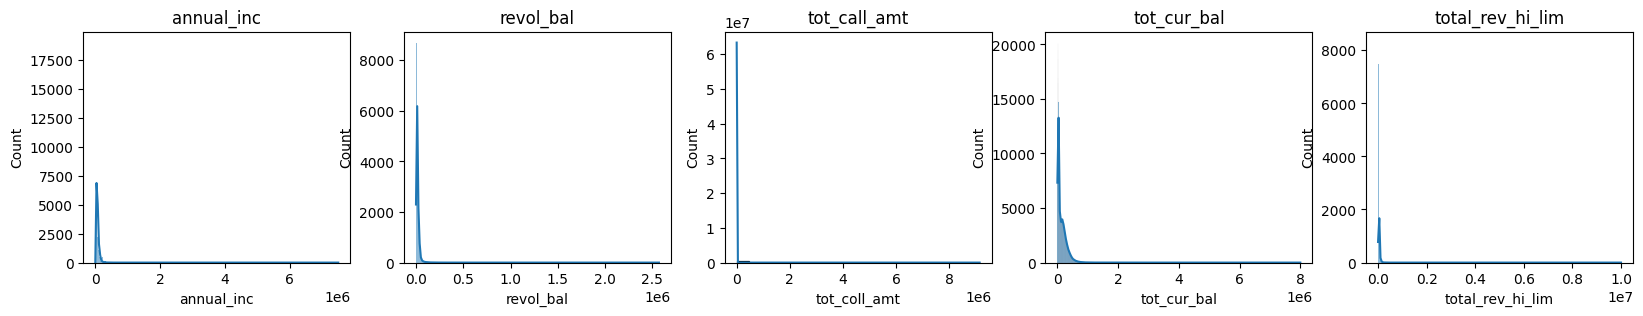

None

In [8]:
# histogarm
fig, ax = plt.subplots(1,5, figsize = (20,3))
sns.histplot(df, x = 'annual_inc', kde = True, ax = ax[0])
sns.histplot(df, x = 'revol_bal', kde = True, ax = ax[1])
sns.histplot(df, x = 'tot_coll_amt', kde = True, ax = ax[2])
sns.histplot(df, x = 'tot_cur_bal', kde = True, ax = ax[3])
sns.histplot(df, x = 'total_rev_hi_lim', kde = True, ax = ax[4])
ax[0].set_title('annual_inc')
ax[1].set_title('revol_bal')
ax[2].set_title('tot_call_amt')
ax[3].set_title('tot_cur_bal')
ax[4].set_title('total_rev_hi_lim')
display(plt.show())

In [9]:
print("Percntage higher than 99% Annual Income : ", df[df['annual_inc']>= df['annual_inc'].quantile(0.99)].shape[0]/df.shape[0] * 100)
print("Percntage higher than 99% revol_bal : ", df[df['revol_bal']>= df['revol_bal'].quantile(0.99)].shape[0]/df.shape[0] * 100)
print("Percntage higher than 99% tot_coll_amt : ", df[df['tot_coll_amt']>= df['tot_coll_amt'].quantile(0.99)].shape[0]/df.shape[0] * 100)
print("Percntage higher than 99% tot_cur_bal : ", df[df['tot_cur_bal']>= df['tot_cur_bal'].quantile(0.99)].shape[0]/df.shape[0] * 100)
print("Percntage higher than 99% total_rev_hi_lim : ", df[df['total_rev_hi_lim']>= df['total_rev_hi_lim'].quantile(0.99)].shape[0]/df.shape[0] * 100)

Percntage higher than 99% Annual Income :  1.001970914534369
Percntage higher than 99% revol_bal :  1.0000407479609934
Percntage higher than 99% tot_coll_amt :  0.8494877552377215
Percntage higher than 99% tot_cur_bal :  0.8494877552377215
Percntage higher than 99% total_rev_hi_lim :  0.8503456070481105


In [10]:
# split data to : current, non_current
# non_current data : default , non default , use for training, validation, test model
# current data : the model used to predict what happen to the current customer

current_data = df[df['loan_status'].isin(['Current', 'Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period'])].copy()
model_data = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Does not meet the credit policy. Status:Fully Paid',
                                        'Does not meet the credit policy. Status:Charged Off', 'Default'])].copy()

# 1 default, non-default = 0
model_data['loan_status'] = np.where(model_data['loan_status'].isin(['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']), 0, 1)

Only loans with resolved outcomes were used to train the PD model. Fully Paid loans were classified as non-default, while Charged Off and Default loans were classified as default. Loans that remained Current, Late, or In Grace Period were excluded from model fitting because their ultimate outcome was still unknown. The resulting development population is moderately imbalanced, with approximately 19% defaults.

loan_status
0    80.905668
1    19.094332
Name: proportion, dtype: float64


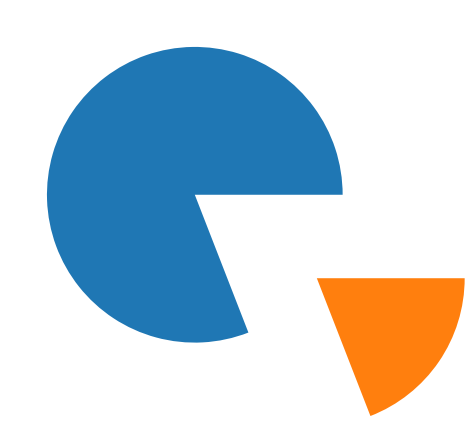

In [11]:
print(model_data['loan_status'].value_counts(normalize = True) * 100 )
# plot the classes of the target
target  = model_data['loan_status'].value_counts(normalize = True) * 100
plt.pie(target.values, target.index);

In [12]:

model_data[model_data['issue_y'] <2014]['loan_status'].value_counts(normalize = True)

,proportion
loan_status,
0,0.81748
1,0.18252


In [13]:
model_data[model_data['issue_y'] == 2014]['loan_status'].value_counts(normalize = True)

,proportion
loan_status,
0,0.78943
1,0.21057


In [14]:
model_data_2 = model_data.copy()

X_train = model_data_2[model_data_2['issue_y']<2014]
X_train.drop(columns = 'loan_status', inplace = True)
X_test = model_data_2[model_data_2['issue_y']>=2014]
X_test.drop(columns = 'loan_status', inplace = True)
y_train = model_data_2[model_data_2['issue_y']<2014]['loan_status']
y_test = model_data_2[model_data_2['issue_y']>=2014]['loan_status']

Rather than using a purely random final train-test split, loans were separated chronologically. Pre-2014 loans form the development sample and 2014 loans form the out-of-time test sample. This provides a more realistic assessment of how a model estimated on historical vintages would perform on subsequently originated loans.

##### **Coarse Binning Numerical Variables**
- Greedy Binning Method : Numerical variables were first coarse-classed using a supervised decision tree with entropy as the splitting criterion. The algorithm selects thresholds that separate defaults from non-defaults while limiting the maximum number of bins and enforcing a minimum bin size. This allows nonlinear relationships to be represented in a form suitable for WoE transformation while avoiding excessively small bins. Bin boundaries are estimated using the development sample and then applied unchanged to the out-of-time test sample.


In [15]:
# 1- greedy binning method
from sklearn.tree import DecisionTreeClassifier

def greedy_numeric_binning(x, y, max_bins=5, min_bin_size=0.05):
    """
    Greedy supervised binning for one numerical variable.

    x : numerical feature
    y : binary target, 0 = non-default, 1 = default
    max_bins : maximum number of bins
    min_bin_size : minimum proportion of observations in each bin
    """

    df = pd.DataFrame({"x": x,"y": y}).dropna()
    X = df[["x"]]
    y_clean = df["y"]
    tree = DecisionTreeClassifier(criterion="entropy",max_leaf_nodes=max_bins,min_samples_leaf=min_bin_size,random_state=42)
    tree.fit(X, y_clean)
    # Extract split points
    thresholds = tree.tree_.threshold
    thresholds = thresholds[thresholds != -2]
    thresholds = np.sort(thresholds)
    # Create complete bin boundaries
    bins = [-np.inf] + thresholds.tolist() + [np.inf]
    return bins

In [16]:
X_num = X_train.select_dtypes(include=["int64", "float64"]).copy()
X_num_test = X_test.select_dtypes(include=["int64", "float64"]).copy()
for i in X_num.columns:

  bins = greedy_numeric_binning(X_num[i], y_train, max_bins=10, min_bin_size=1500)
  X_num.loc[:,i] = pd.cut(X_num[i], bins=bins, labels=None)
  X_num_test.loc[:,i] = pd.cut(X_num_test[i], bins=bins, labels=None)


X_cat = X_train.select_dtypes(include=["object"]).copy()
X_cat_test = X_test.select_dtypes(include=["object"]).copy()
X_binned = pd.concat([X_num, X_cat], axis=1)
X_binned_test = pd.concat([X_num_test, X_cat_test], axis=1)


In [17]:
# define a category missing for columns : tot_coll_amt, tot_cur_bal, total_rev_hi_lim
# dop other rows with nan value
column_with_nan = ['tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim']
for col in column_with_nan:
  X_binned[col] = np.where(X_binned[col].isna(), 'missing', X_binned[col])
  X_binned_test[col] = np.where(X_binned_test[col].isna(), 'missing', X_binned_test[col])

X_binned.dropna(inplace=True)
X_binned_test.dropna(inplace=True)
y_train = y_train[X_binned.index]
y_test = y_test[X_binned_test.index]

Weight of Evidence transforms each bin according to the relative concentration of defaults and non-defaults. Under the convention used in this project, positive WoE indicates greater relative concentration of defaults, while negative WoE indicates greater relative concentration of non-defaults. WoE is particularly useful for scorecards because it allows nonlinear and categorical relationships to enter logistic regression in an interpretable form.

In [18]:
class WoEEncoder(BaseEstimator, TransformerMixin):

    def __init__(self, eps=0.0001):
        self.eps = eps

    def fit(self, X, y):

        if isinstance(X, pd.DataFrame):
            X = X.copy()
        else:
            X = pd.DataFrame(X)

        self.feature_names_in_ = np.array(X.columns,dtype=object)
        y = pd.Series(np.asarray(y),index=X.index)
        self.woe_dict_ = {}
        self.iv_ = {}
        self.iv_table_ = {}
        for col in X.columns:
            x_col = (X[col].astype("object").fillna("MISSING"))
            temp = pd.DataFrame({"feature": x_col,"target": y})
            grouped = (temp.groupby("feature", observed=False)["target"])
            event = grouped.sum()
            non_event = grouped.count() - event
            event_dist = event / event.sum()
            non_event_dist = non_event / non_event.sum()
            woe = np.log((event_dist + self.eps) /(non_event_dist + self.eps))
            # IV for every bin
            iv_bin = (event_dist - non_event_dist) * woe
            # Store WoE
            self.woe_dict_[col] = woe.to_dict()
            # Store total IV
            self.iv_[col] = iv_bin.sum()
            # Store detailed table
            self.iv_table_[col] = pd.DataFrame({
                "event": event,
                "non_event": non_event,
                "event_dist": event_dist,
                "non_event_dist": non_event_dist,
                "woe": woe,
                "iv_bin": iv_bin})
        return self
    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.copy()
        else:
            X = pd.DataFrame(X,columns=self.feature_names_in_)
        X_encoded = pd.DataFrame(index=X.index)
        for col in self.feature_names_in_:
            x_col = X[col].astype("object").fillna("MISSING")
            X_encoded[col] = (x_col.map(self.woe_dict_[col]).fillna(0).astype(float))
        return X_encoded
    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_in_, dtype=object)

In [19]:
zip_bin = pd.DataFrame(X_binned['zip_code'].value_counts())
less_100 = (zip_bin[zip_bin['count']<100]).index
bet_100_200 = (zip_bin[(zip_bin['count']<200) & (zip_bin['count']>=100)]).index
bet_200_300 = (zip_bin[(zip_bin['count']<300) & (zip_bin['count']>=200)]).index
bet_300_400 = (zip_bin[(zip_bin['count']<400) & (zip_bin['count']>=300)]).index
bet_400_500 = (zip_bin[(zip_bin['count']<500) & (zip_bin['count']>=400)]).index
bet_500_600 = (zip_bin[(zip_bin['count']<600) & (zip_bin['count']>=500)]).index
bet_600_700 = (zip_bin[(zip_bin['count']<700) & (zip_bin['count']>=600)]).index
bet_700_800 = (zip_bin[(zip_bin['count']<800) & (zip_bin['count']>=700)]).index
bet_800_900 = (zip_bin[(zip_bin['count']<900) & (zip_bin['count']>=800)]).index
more_1000 = (zip_bin[zip_bin['count']>=1000]).index

X_binned.loc[X_binned["zip_code"].isin(less_100),"zip_code"] = "less_100"
X_binned.loc[X_binned["zip_code"].isin(bet_100_200),"zip_code"] = "bet_100_200"
X_binned.loc[X_binned["zip_code"].isin(bet_200_300),"zip_code"] = "bet_200_300"
X_binned.loc[X_binned["zip_code"].isin(bet_300_400),"zip_code"] = "bet_300_400"
X_binned.loc[X_binned["zip_code"].isin(bet_400_500),"zip_code"] = "bet_400_500"
X_binned.loc[X_binned["zip_code"].isin(bet_500_600),"zip_code"] = "bet_500_600"
X_binned.loc[X_binned["zip_code"].isin(bet_600_700),"zip_code"] = "bet_600_700"
X_binned.loc[X_binned["zip_code"].isin(bet_700_800),"zip_code"] = "bet_700_800"
X_binned.loc[X_binned["zip_code"].isin(bet_800_900),"zip_code"] = "bet_800_900"
X_binned.loc[X_binned["zip_code"].isin(more_1000),"zip_code"] = "more_1000"

In [20]:
state_count = X_binned["addr_state"].value_counts()

less_1000 = state_count[state_count < 1000].index
bet_1000_2000 = state_count[(state_count >= 1000) & (state_count < 2000)].index
bet_2000_3000 = state_count[(state_count >= 2000) & (state_count < 3000)].index
bet_3000_4000 = state_count[(state_count >= 3000) & (state_count < 4000)].index
bet_4000_5000 = state_count[(state_count >= 4000) & (state_count < 5000)].index
bet_5000_6000 = state_count[(state_count >= 5000) & (state_count < 6000)].index
bet_6000_10000 = state_count[(state_count >= 6000) & (state_count < 10000)].index

X_binned.loc[X_binned["addr_state"].isin(less_1000),"addr_state"] = "less_1000"
X_binned.loc[X_binned["addr_state"].isin(bet_1000_2000),"addr_state"] = "1000_2000"
X_binned.loc[X_binned["addr_state"].isin(bet_2000_3000),"addr_state"] = "2000_3000"
X_binned.loc[X_binned["addr_state"].isin(bet_3000_4000),"addr_state"] = "3000_4000"
X_binned.loc[X_binned["addr_state"].isin(bet_4000_5000),"addr_state"] = "4000_5000"
X_binned.loc[X_binned["addr_state"].isin(bet_5000_6000),"addr_state"] = "5000_6000"
X_binned.loc[X_binned["addr_state"].isin(bet_6000_10000),"addr_state"] = "6000_10000"

Information Value was used as an initial univariate screening measure. Variables with IV below 0.02 were excluded from the candidate scorecard set. IV was not treated as the sole selection rule; correlation, stability, business interpretation, and potential redundancy were considered subsequently.

In [21]:
woe_encoder = WoEEncoder()
woe_encoder.fit(X_binned, y_train)
X_woe = woe_encoder.transform(X_binned)
X_woe_test = woe_encoder.transform(X_binned_test)
iv_df = (pd.Series(woe_encoder.iv_, name="IV").sort_values(ascending=False).to_frame())
display(iv_df)

,IV
int_rate,0.396696
sub_grade,0.391819
grade,0.363092
term,0.167908
revol_util,0.066203
dti,0.065089
annual_inc,0.050984
funded_amnt,0.041200
loan_amnt,0.041163
tot_cur_bal,0.039545


In [22]:
X_train_iv = X_woe[iv_df[iv_df['IV']>=0.02].index]
X_test_iv = X_woe_test[iv_df[iv_df['IV']>=0.02].index]


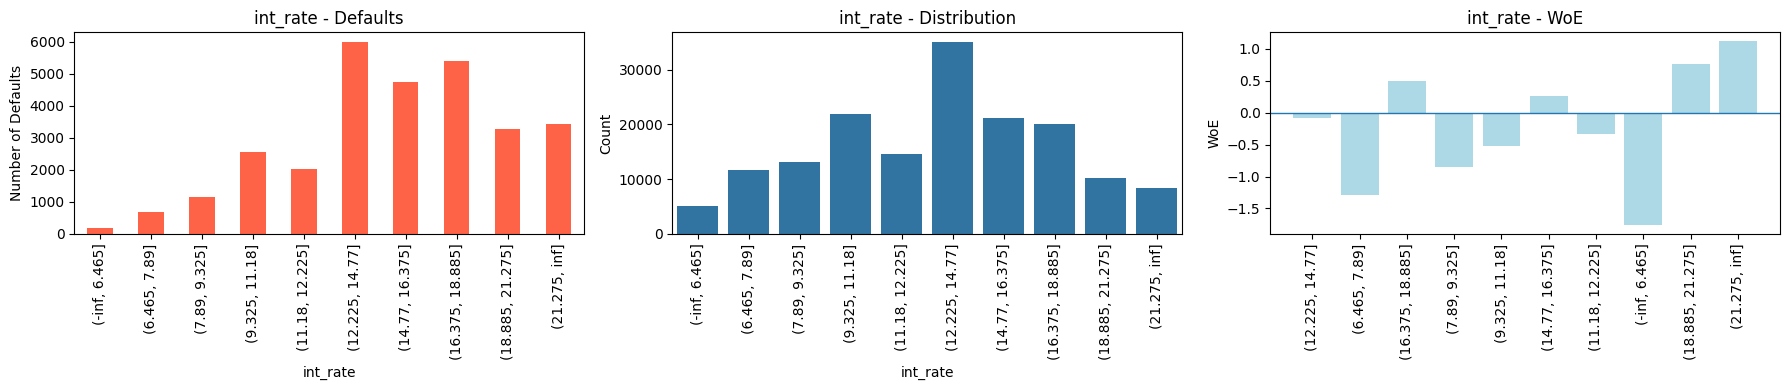

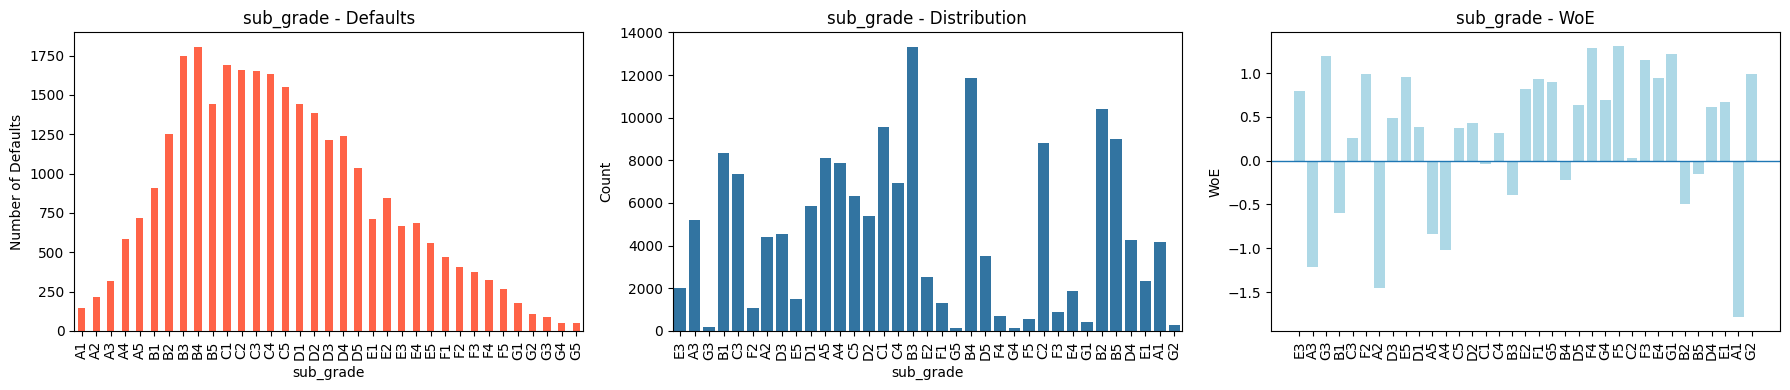

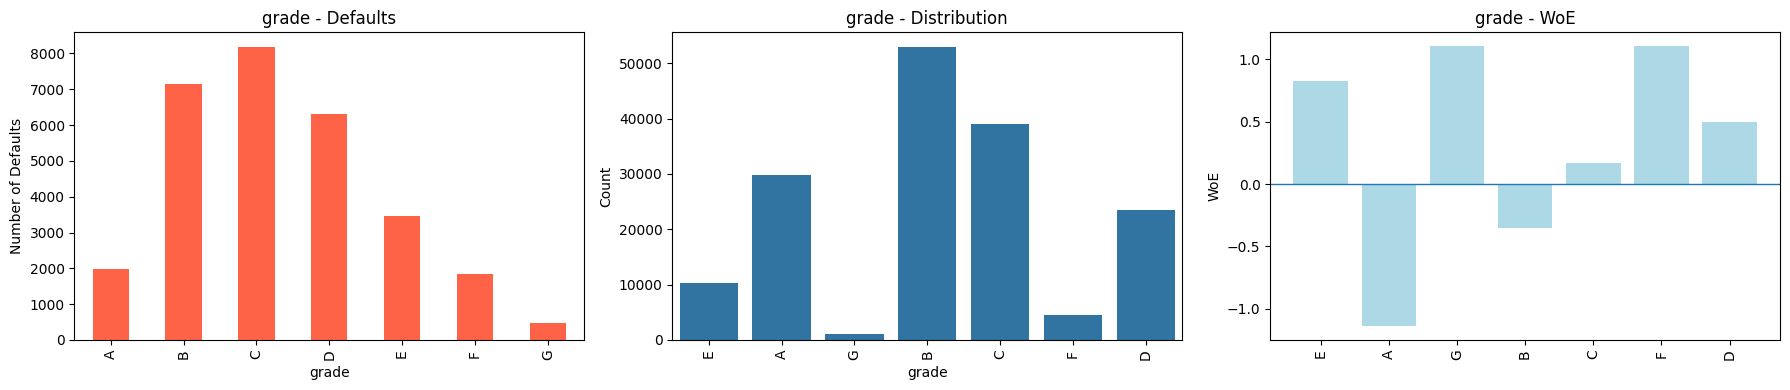

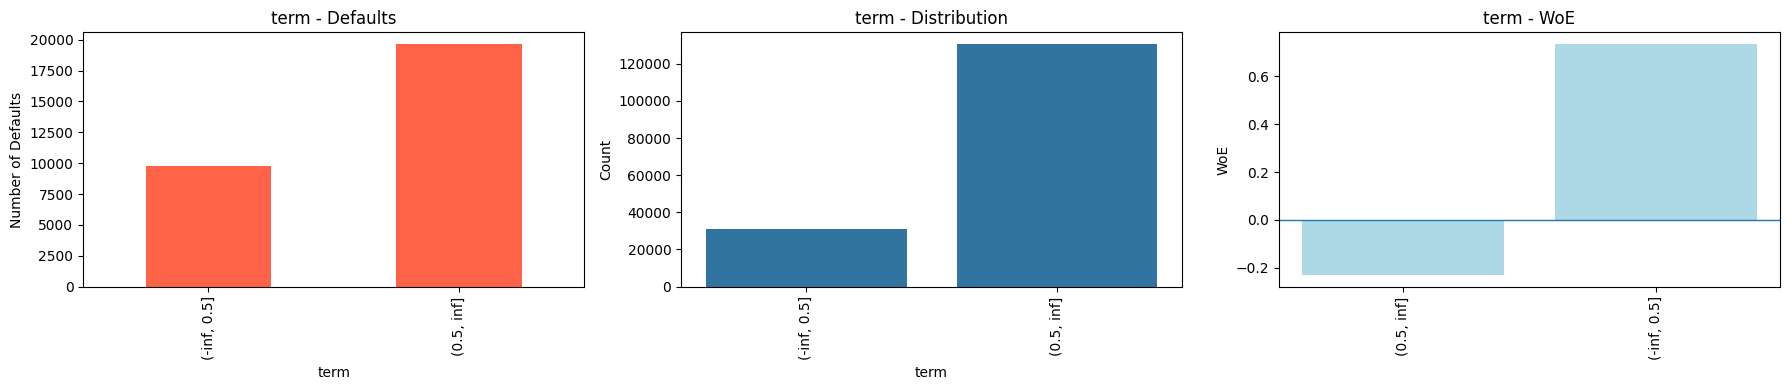

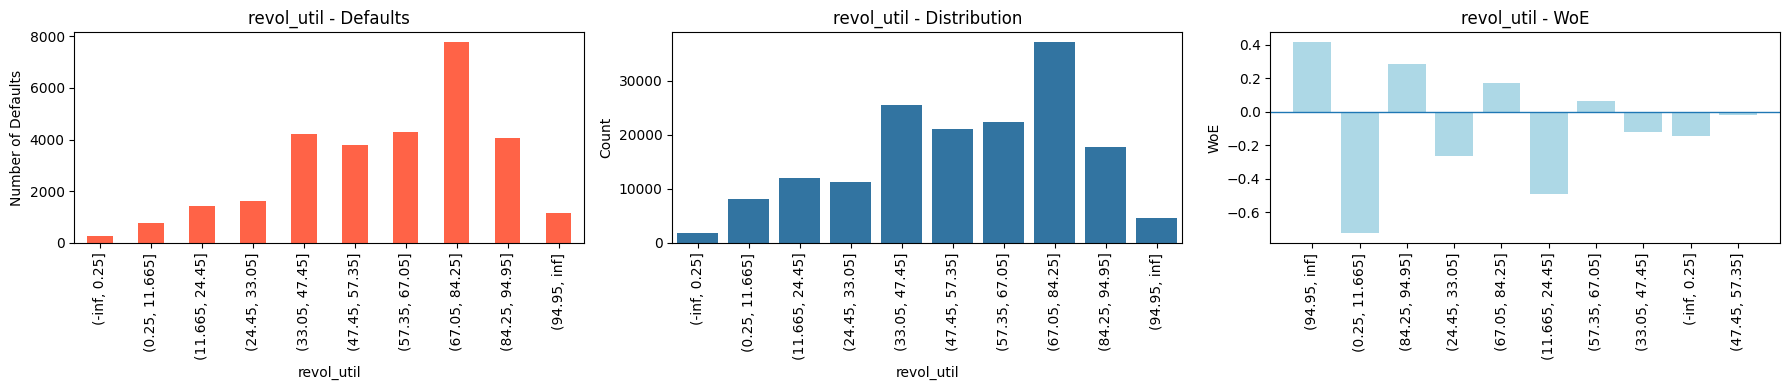

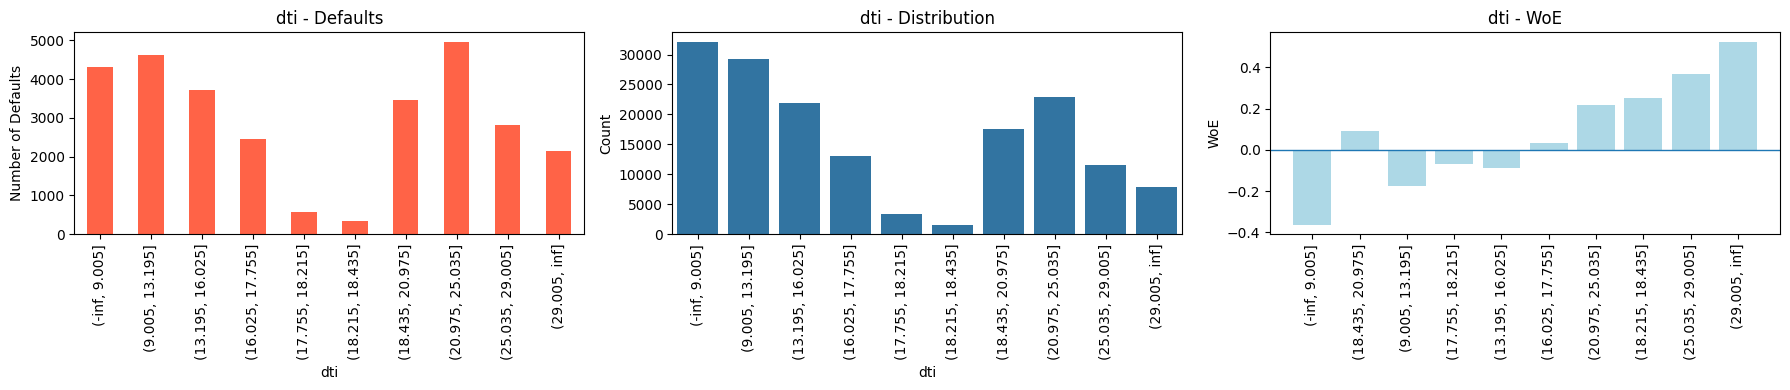

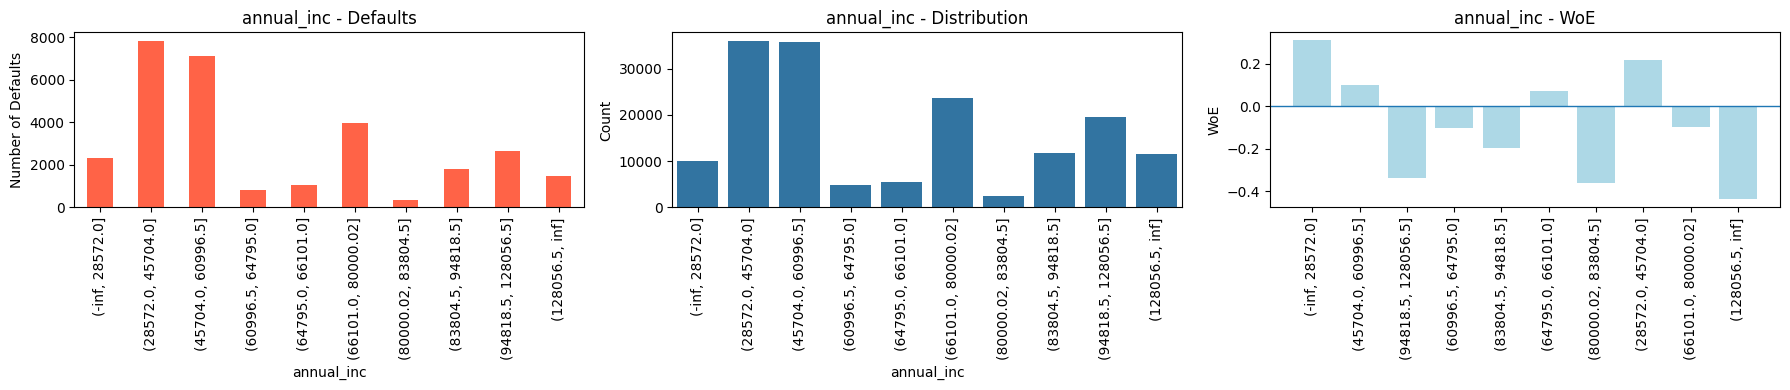

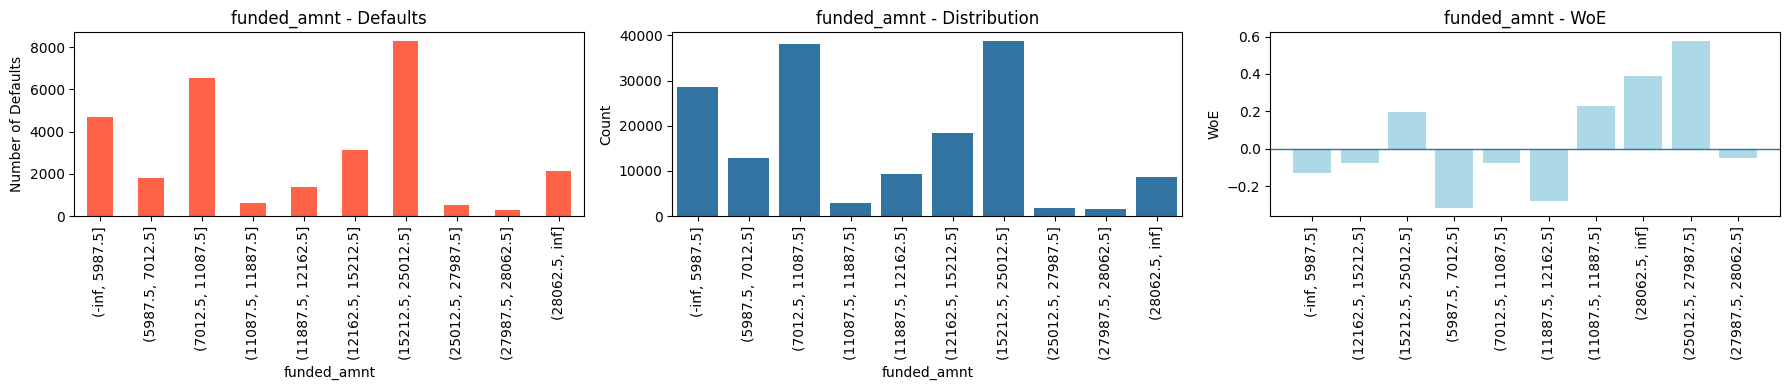

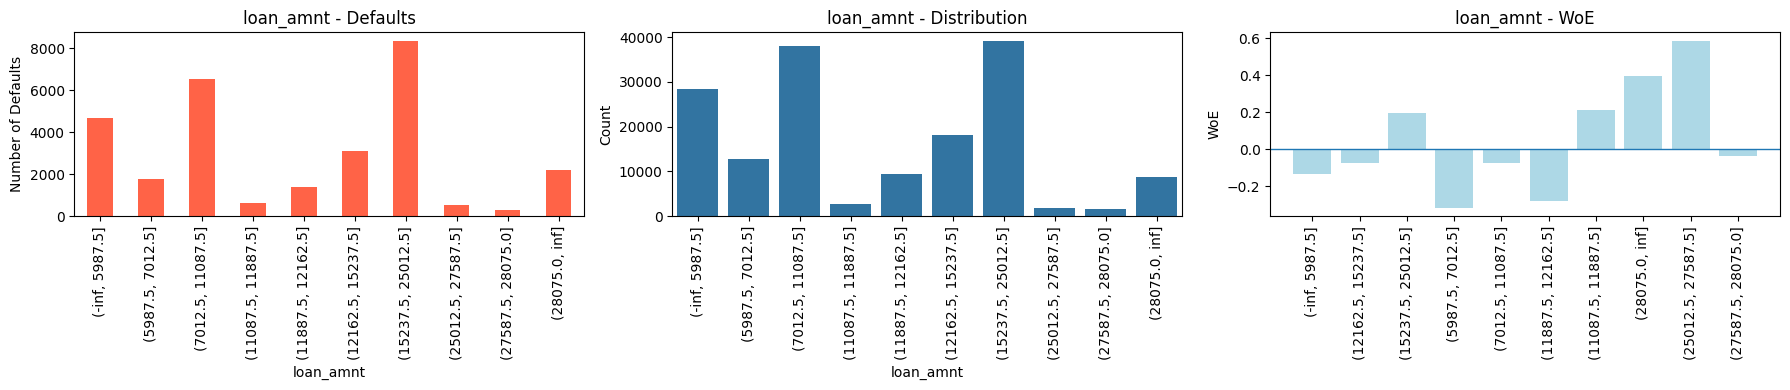

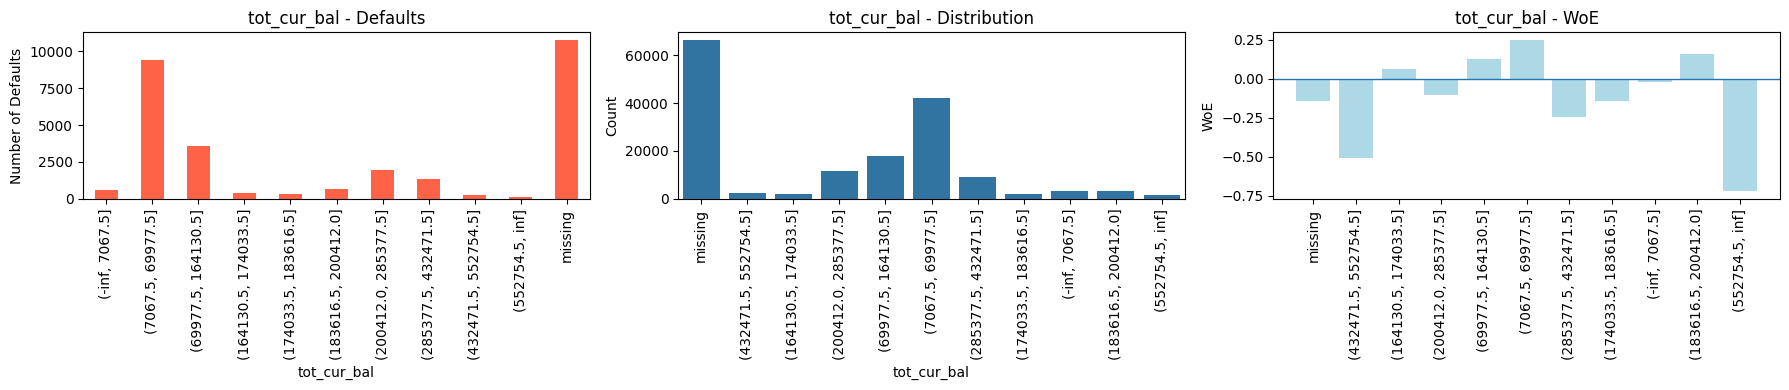

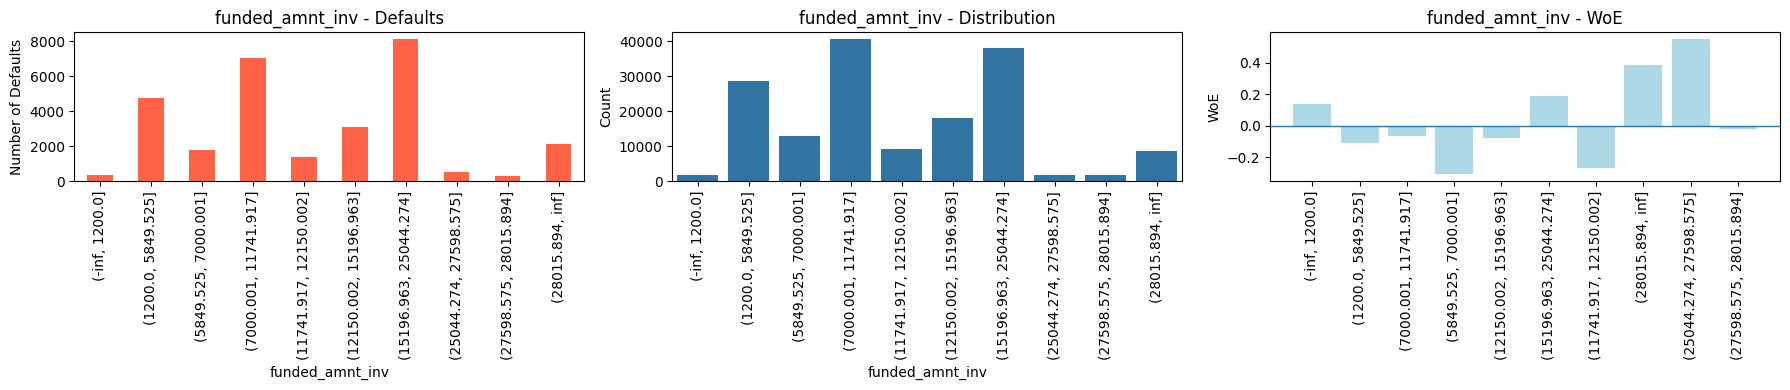

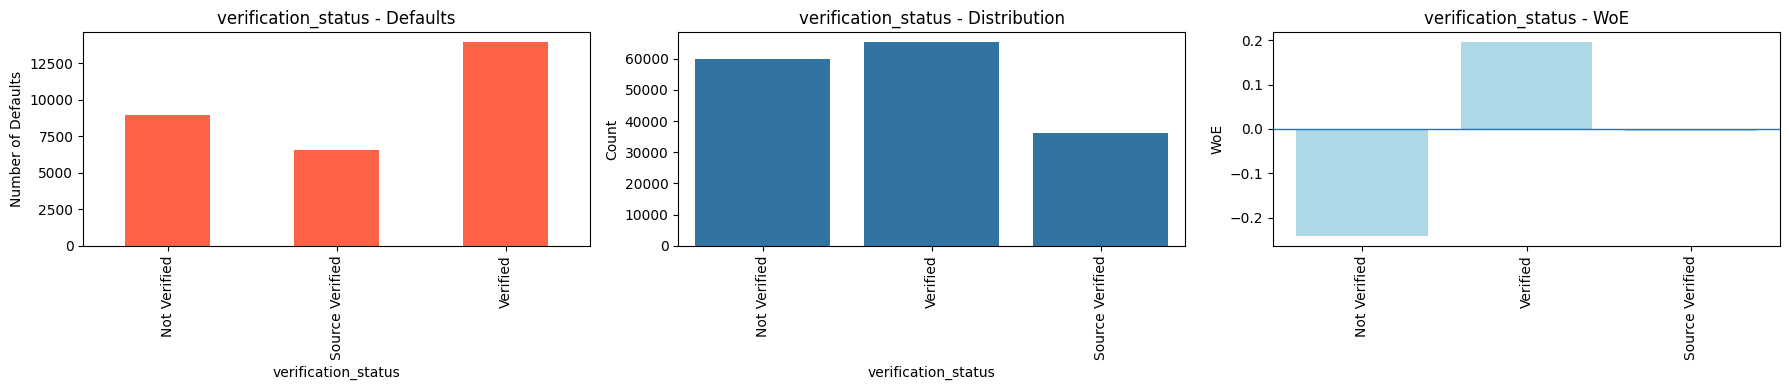

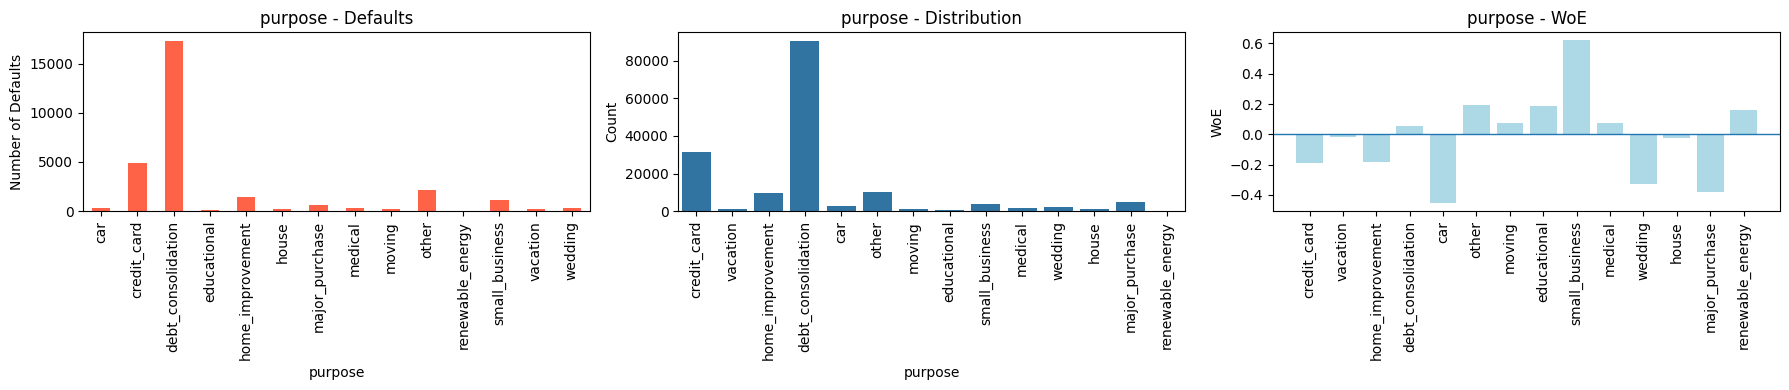

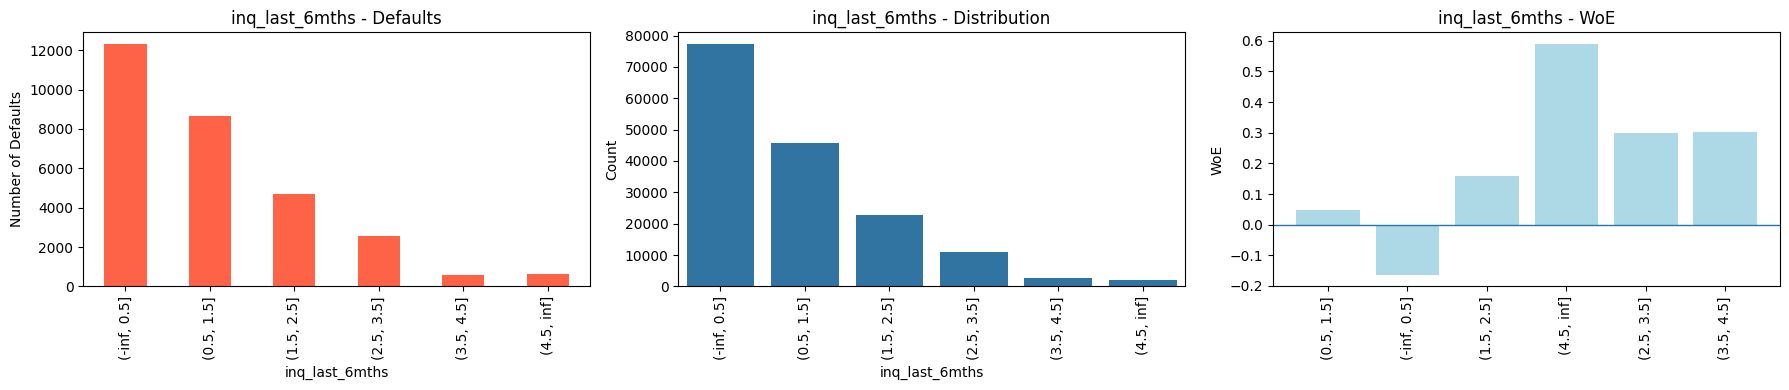

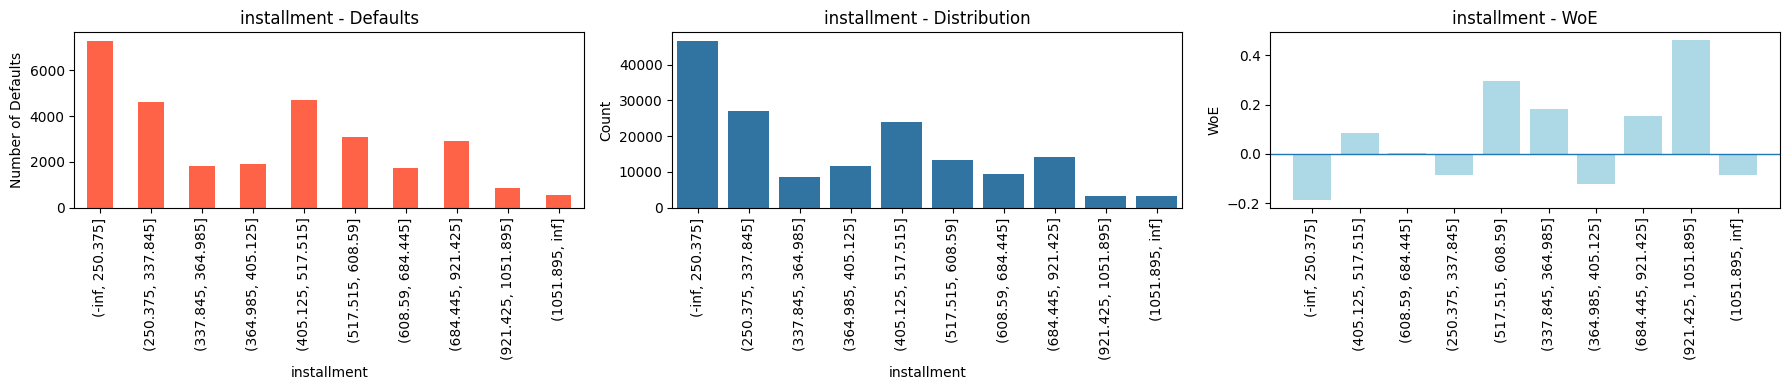

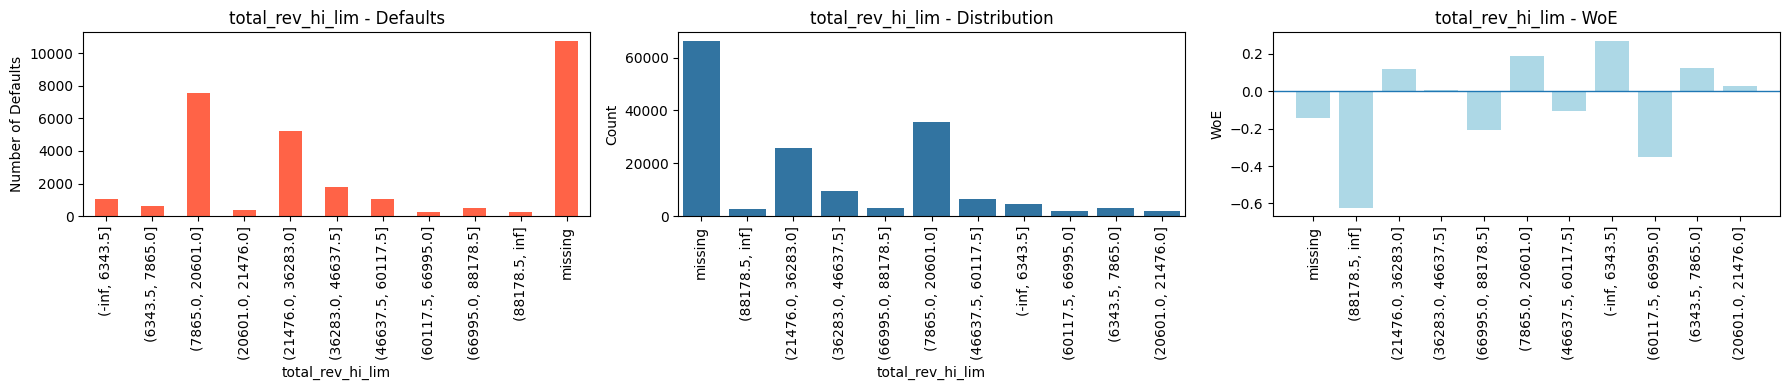

In [23]:
def plot_woe_bin(col, X_binned,X_woe):
    # Combine bin, WoE, and target
    df_bin = X_binned[[col]].copy()
    df_bin[col + "_woe"] = X_woe[col].values
    df_bin["target"] = y_train.values

    # Create 3 plots
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))
    # 1. Number of defaults in each bin
    (df_bin.groupby(col, observed=False)["target"].sum().plot(kind="bar", ax=ax[0], color ='tomato'))
    ax[0].set_title(f"{col} - Defaults")
    ax[0].set_ylabel("Number of Defaults")
    ax[0].tick_params(axis="x", rotation=90)
    # 2. Number of observations in each bin
    sns.countplot(data=df_bin,x=col,ax=ax[1])
    ax[1].set_title(f"{col} - Distribution")
    ax[1].set_ylabel("Count")
    ax[1].tick_params(axis="x", rotation=90)
    # 3. WoE by bin
    woe_table = (df_bin[[col, col + "_woe"]].drop_duplicates().reset_index(drop=True))
    ax[2].bar(woe_table[col].astype(str),woe_table[col + "_woe"], color = 'lightblue')
    ax[2].set_title(f"{col} - WoE")
    ax[2].set_ylabel("WoE")
    ax[2].tick_params(axis="x", rotation=90)
    ax[2].axhline(0, linewidth=1)
    plt.tight_layout()
    plt.show()

for col in X_train_iv.columns:
    plot_woe_bin(col, X_binned,X_woe)

**Fine Tunning**

For WoE bin fine-tuning,usually consider merging bins when they are:

- low frequency: very few observations
- similar WoE: they show nearly the same risk level
- ideally also similar default rates

Coarse bins were reviewed for stability and business interpretability. Adjacent bins with similar WoE/default rates, low observation counts, or noisy local movements were combined. Fine classing reduces unnecessary fragmentation and produces more stable risk groups. After all mergers, WoE and IV were recalculated because changes in bin composition alter both default and non-default distributions.

In [24]:
X_binned_2 = X_binned.copy()
X_binned_test_2 = X_binned_test.copy()

grade_mapping = {'F': 'F_G','G': 'F_G'}
X_binned_2['grade'] = X_binned_2['grade'].astype('string').replace(grade_mapping)
X_binned_test_2['grade']  = X_binned_test_2['grade'].astype('string').replace(grade_mapping)

X_binned_2['dti'] = X_binned_2['dti'].astype(str).replace({'(16.025, 17.755]': '(16.025, 18.215]','(17.755, 18.215]': '(16.025, 18.215]', '(18.215, 18.435]': '(18.215, 20.975]','(18.435, 20.975]': '(18.215, 20.975]'})
X_binned_test_2['dti'] = X_binned_test_2['dti'].astype(str).replace({'(16.025, 17.755]': '(16.025, 18.215]','(17.755, 18.215]': '(16.025, 18.215]', '(18.215, 18.435]': '(18.215, 20.975]','(18.435, 20.975]': '(18.215, 20.975]'})

X_binned_2['revol_util'] = X_binned_2['revol_util'].astype(str).replace({'(-inf, 0.25]': '(-inf, 11.665]','(0.25, 11.665]': '(-inf, 11.665]'})
X_binned_test_2['revol_util'] = X_binned_test_2['revol_util'].astype(str).replace({'(-inf, 0.25]': '(-inf, 11.665]','(0.25, 11.665]': '(-inf, 11.665]'})

X_binned_2['annual_inc'] = X_binned_2['annual_inc'].astype(str).replace({'(60996.5, 64795.0]': '(60996.5, 80000.02]','(64795.0, 66101.0]': '(60996.5, 80000.02]',
    '(66101.0, 80000.02]': '(60996.5, 80000.02]','(80000.02, 83804.5]': '(80000.02, 94818.5]','(83804.5, 94818.5]': '(80000.02, 94818.5]'})
X_binned_test_2['annual_inc'] = X_binned_test_2['annual_inc'].astype(str).replace({'(60996.5, 64795.0]': '(60996.5, 80000.02]','(64795.0, 66101.0]': '(60996.5, 80000.02]', '(66101.0, 80000.02]': '(60996.5, 80000.02]',
                                                                                       '(80000.02, 83804.5]': '(80000.02, 94818.5]','(83804.5, 94818.5]': '(80000.02, 94818.5]'})

X_binned_2['loan_amnt'] = X_binned_2['loan_amnt'].astype(str).replace({
    # Merge first two
    '(-inf, 5987.5]': '(-inf, 7012.5]','(5987.5, 7012.5]': '(-inf, 7012.5]',
    # Merge middle noisy bins
    '(7012.5, 11087.5]': '(7012.5, 15237.5]','(11087.5, 11887.5]': '(7012.5, 15237.5]','(11887.5, 12162.5]': '(7012.5, 15237.5]','(12162.5, 15237.5]': '(7012.5, 15237.5]',
    # Merge high-loan noisy bins
    '(25012.5, 27587.5]': '(25012.5, 28075.0]','(27587.5, 28075.0]': '(25012.5, 28075.0]'})


X_binned_test_2['loan_amnt'] = X_binned_test_2['loan_amnt'].astype(str).replace({

    # Merge first two
    '(-inf, 5987.5]': '(-inf, 7012.5]','(5987.5, 7012.5]': '(-inf, 7012.5]',
    # Merge middle noisy bins
    '(7012.5, 11087.5]': '(7012.5, 15237.5]','(11087.5, 11887.5]': '(7012.5, 15237.5]','(11887.5, 12162.5]': '(7012.5, 15237.5]','(12162.5, 15237.5]': '(7012.5, 15237.5]',
    # Merge high-loan noisy bins
    '(25012.5, 27587.5]': '(25012.5, 28075.0]','(27587.5, 28075.0]': '(25012.5, 28075.0]'})


X_binned_2['tot_cur_bal'] = X_binned_2['tot_cur_bal'].astype(str).replace({
    '(164130.5, 174033.5]': '(164130.5, 200412.0]','(174033.5, 183616.5]': '(164130.5, 200412.0]','(183616.5, 200412.0]': '(164130.5, 200412.0]'})

X_binned_test_2['tot_cur_bal'] = X_binned_test_2['tot_cur_bal'].astype(str).replace({
    '(164130.5, 174033.5]': '(164130.5, 200412.0]','(174033.5, 183616.5]': '(164130.5, 200412.0]','(183616.5, 200412.0]': '(164130.5, 200412.0]'})

X_binned_2['inq_last_6mths'] = X_binned_2['inq_last_6mths'].astype(str).replace({'(2.5, 3.5]': '(2.5, 4.5]','(3.5, 4.5]': '(2.5, 4.5]'})
X_binned_test_2['inq_last_6mths'] = X_binned_test_2['inq_last_6mths'].astype(str).replace({'(2.5, 3.5]': '(2.5, 4.5]','(3.5, 4.5]': '(2.5, 4.5]'})


X_binned_2['purpose'] = X_binned_2['purpose'].astype(str).replace({
    # Lower WoE
    'car': 'car_majorpurchase_wedding','major_purchase': 'car_majorpurchase_wedding','wedding': 'car_majorpurchase_wedding',
    # Similar WoE around -0.19
    'credit_card': 'creditcard_homeimprovement', 'home_improvement': 'creditcard_homeimprovement',
    # Similar WoE around 0
    'house': 'house_vacation','vacation': 'house_vacation',
    # Similar WoE around 0.06–0.07
    'debt_consolidation': 'debt_moving_medical','moving': 'debt_moving_medical','medical': 'debt_moving_medical',
    # Similar WoE around 0.16–0.20
    'renewable_energy': 'renewable_education_other','educational': 'renewable_education_other','other': 'renewable_education_other'})

X_binned_test_2['purpose'] = X_binned_test_2['purpose'].astype(str).replace({
    # Lower WoE
    'car': 'car_majorpurchase_wedding','major_purchase': 'car_majorpurchase_wedding','wedding': 'car_majorpurchase_wedding',
    # Similar WoE around -0.19
    'credit_card': 'creditcard_homeimprovement', 'home_improvement': 'creditcard_homeimprovement',
    # Similar WoE around 0
    'house': 'house_vacation','vacation': 'house_vacation',
    # Similar WoE around 0.06–0.07
    'debt_consolidation': 'debt_moving_medical','moving': 'debt_moving_medical','medical': 'debt_moving_medical',
    # Similar WoE around 0.16–0.20
    'renewable_energy': 'renewable_education_other','educational': 'renewable_education_other','other': 'renewable_education_other'})

X_binned_2['installment'] = X_binned_2['installment'].astype(str).replace({

    # Low installment
    '(-inf, 250.375]': '(-inf, 337.845]','(250.375, 337.845]': '(-inf, 337.845]',
    # Middle-low
    '(337.845, 364.985]': '(337.845, 517.515]','(364.985, 405.125]': '(337.845, 517.515]','(405.125, 517.515]': '(337.845, 517.515]',
    # Middle-high
    '(517.515, 608.59]': '(517.515, 921.425]','(608.59, 684.445]': '(517.515, 921.425]','(684.445, 921.425]': '(517.515, 921.425]',
    # High installment
    '(921.425, 1051.895]': '(921.425, inf]', '(1051.895, inf]': '(921.425, inf]'})

X_binned_test_2['installment'] = X_binned_test_2['installment'].astype(str).replace({

    # Low installment
    '(-inf, 250.375]': '(-inf, 337.845]','(250.375, 337.845]': '(-inf, 337.845]',
    # Middle-low
    '(337.845, 364.985]': '(337.845, 517.515]','(364.985, 405.125]': '(337.845, 517.515]','(405.125, 517.515]': '(337.845, 517.515]',
    # Middle-high
    '(517.515, 608.59]': '(517.515, 921.425]','(608.59, 684.445]': '(517.515, 921.425]','(684.445, 921.425]': '(517.515, 921.425]',
    # High installment
    '(921.425, 1051.895]': '(921.425, inf]','(1051.895, inf]': '(921.425, inf]'})

X_binned_2['total_rev_hi_lim'] = (X_binned_2['total_rev_hi_lim'].astype(str).replace({
        # Merge low-middle
        '(6343.5, 7865.0]': '(6343.5, 20601.0]','(7865.0, 20601.0]': '(6343.5, 20601.0]',
        # Merge middle
        '(20601.0, 21476.0]': '(20601.0, 46637.5]','(21476.0, 36283.0]': '(20601.0, 46637.5]','(36283.0, 46637.5]': '(20601.0, 46637.5]',
        # Merge high-middle
        '(60117.5, 66995.0]': '(60117.5, 88178.5]','(66995.0, 88178.5]': '(60117.5, 88178.5]'}))

X_binned_test_2['total_rev_hi_lim'] = (X_binned_test_2['total_rev_hi_lim'].astype(str).replace({
        # Merge low-middle
        '(6343.5, 7865.0]': '(6343.5, 20601.0]','(7865.0, 20601.0]': '(6343.5, 20601.0]',
        # Merge middle
        '(20601.0, 21476.0]': '(20601.0, 46637.5]','(21476.0, 36283.0]': '(20601.0, 46637.5]','(36283.0, 46637.5]': '(20601.0, 46637.5]',
        # Merge high-middle
        '(60117.5, 66995.0]': '(60117.5, 88178.5]','(66995.0, 88178.5]': '(60117.5, 88178.5]' }))

In [25]:
woe_encoder_2 = WoEEncoder()
woe_encoder_2.fit(X_binned_2, y_train)
X_woe_2 = woe_encoder_2.transform(X_binned_2)
X_woe_test_2 = woe_encoder_2.transform(X_binned_test_2)
iv_df = (pd.Series(woe_encoder_2.iv_, name="IV").sort_values(ascending=False).to_frame())
iv_df

,IV
int_rate,0.396696
sub_grade,0.391819
grade,0.363228
term,0.167908
dti,0.064670
revol_util,0.063386
annual_inc,0.049820
funded_amnt,0.041200
tot_cur_bal,0.038902
funded_amnt_inv,0.036889


In [26]:
X_train_iv_2 = X_woe_2[iv_df[iv_df['IV']>=0.02].index]
X_test_iv_2 = X_woe_test_2[iv_df[iv_df['IV']>=0.02].index]

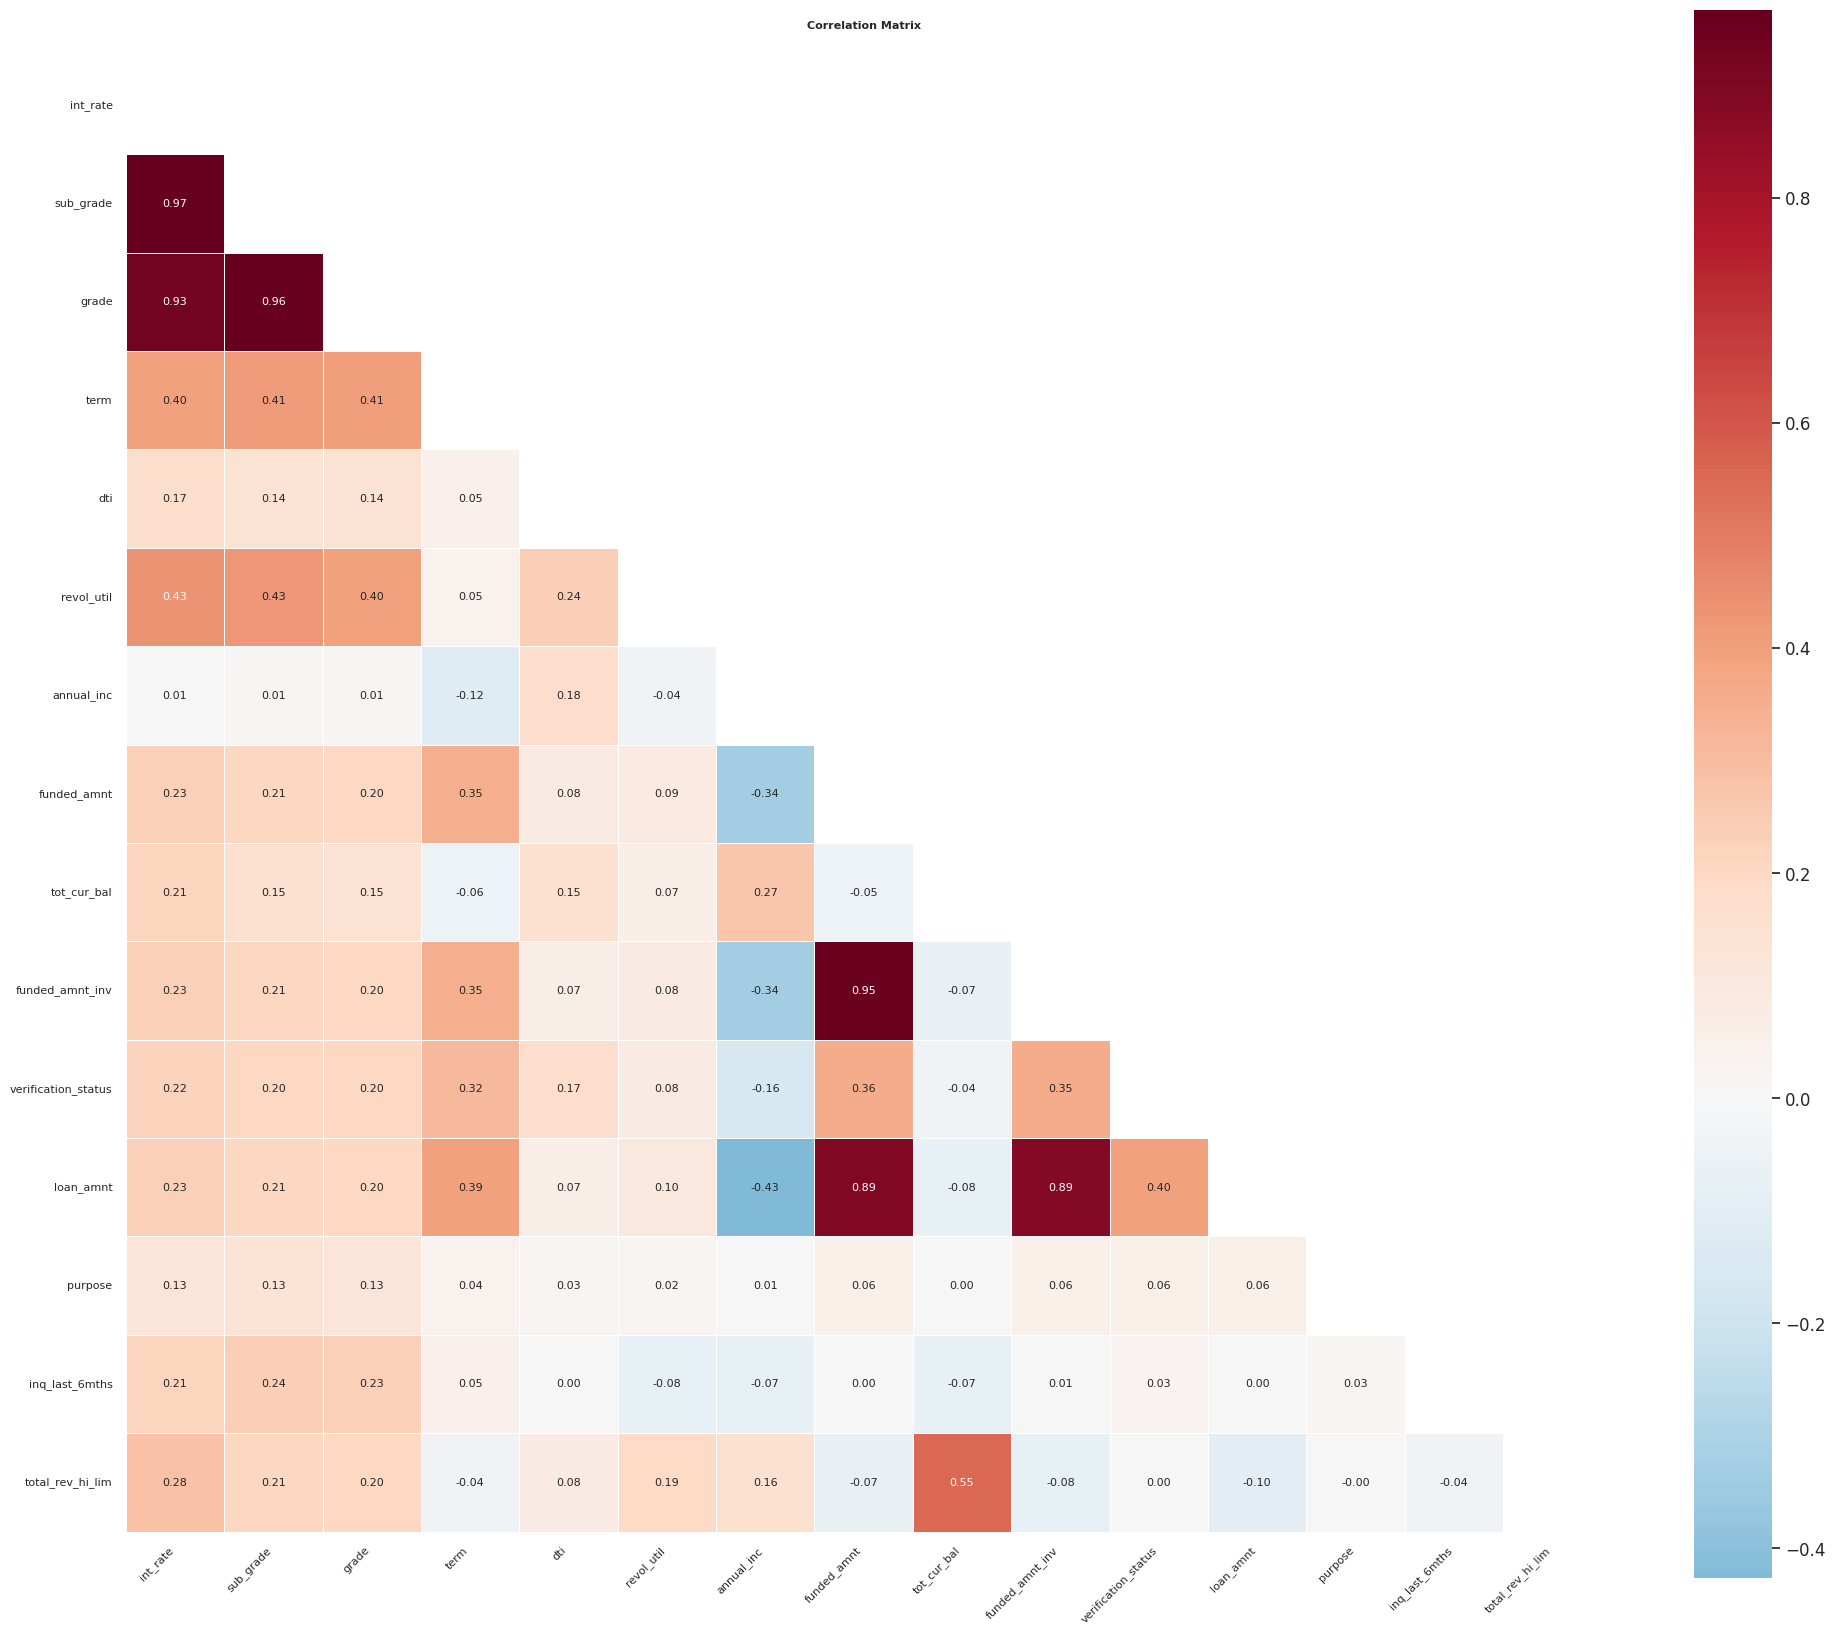

In [27]:
corr = X_train_iv_2.corr(numeric_only=True)
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(20, 20))

sns.set_theme(style="white", font_scale=1.1)

ax = sns.heatmap(corr,mask=mask,annot=True,fmt=".2f",cmap="RdBu_r",center=0,
    square=True,linewidths=0.5,cbar_kws={"shrink": 0.8},annot_kws={"size": 8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=45)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.title("Correlation Matrix",fontsize=8,fontweight="bold",pad=20)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

IV measures each variable individually, but it does not account for redundancy between predictors. Correlation among WoE-transformed variables was therefore reviewed after IV screening. Highly overlapping loan-amount and LendingClub risk-pricing variables were removed to reduce multicollinearity and avoid allowing the same underlying signal to enter the scorecard multiple times.

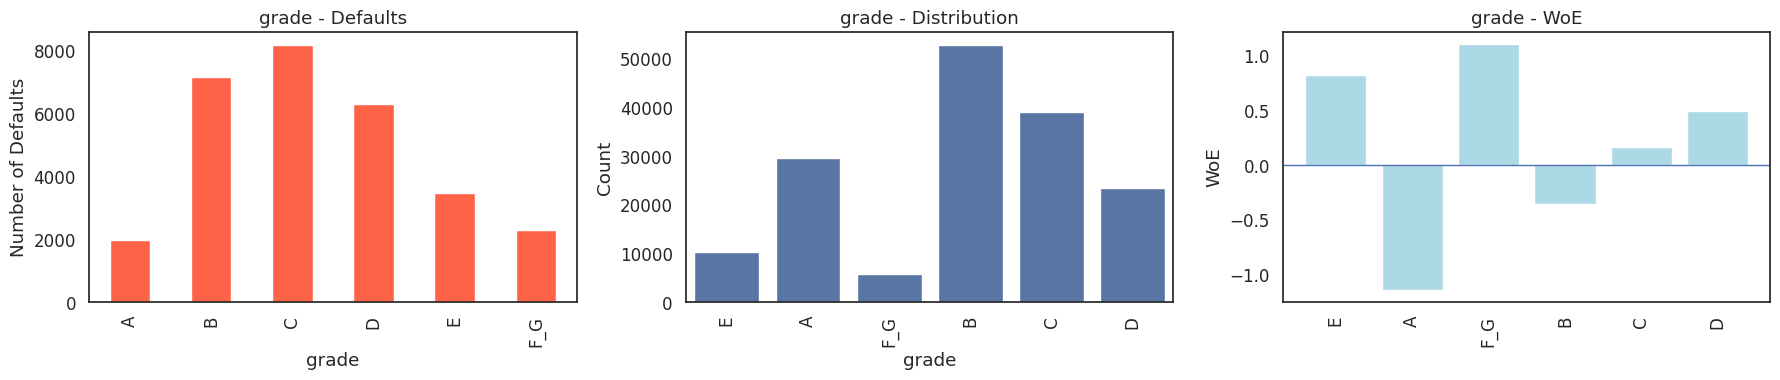

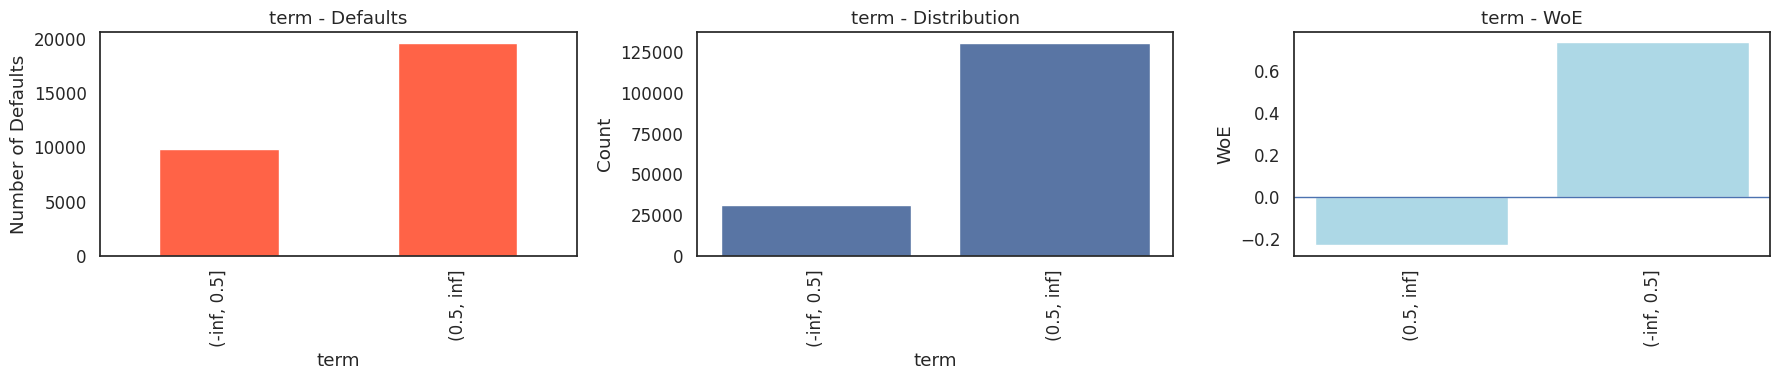

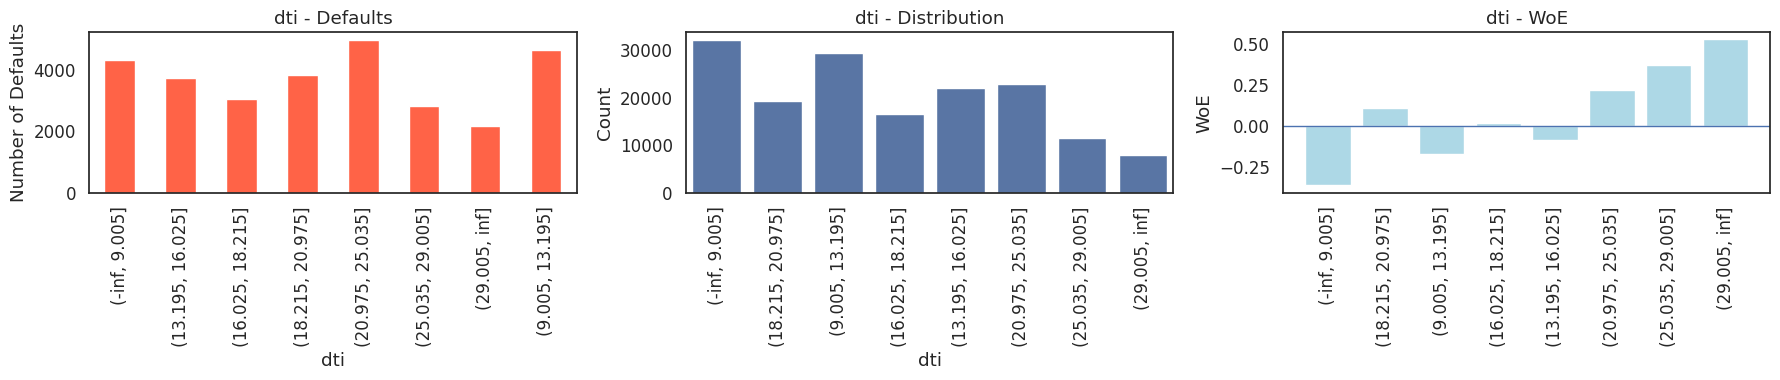

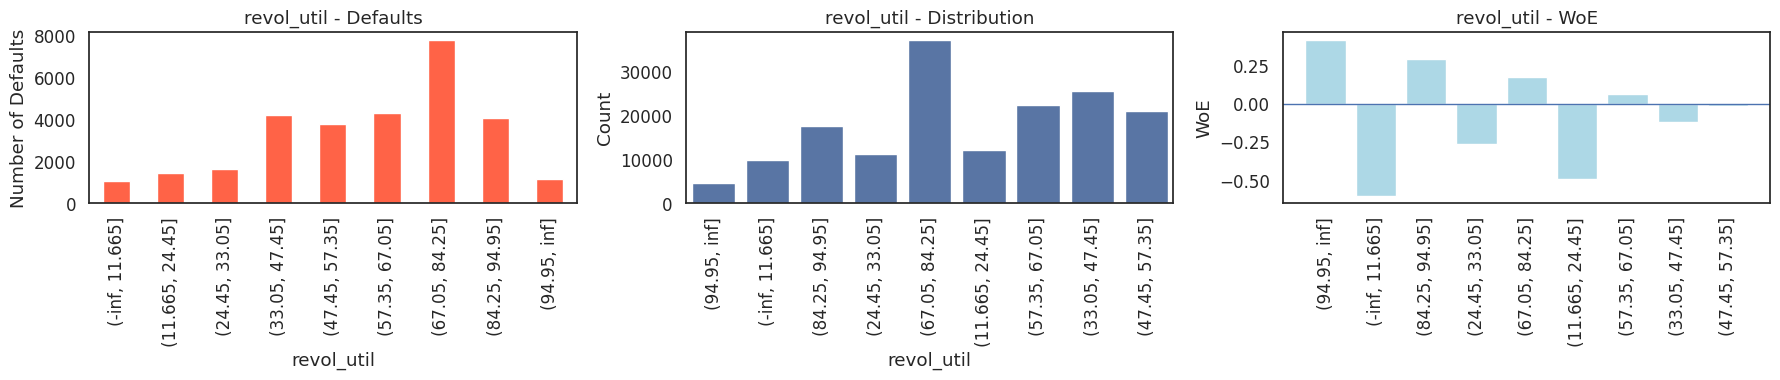

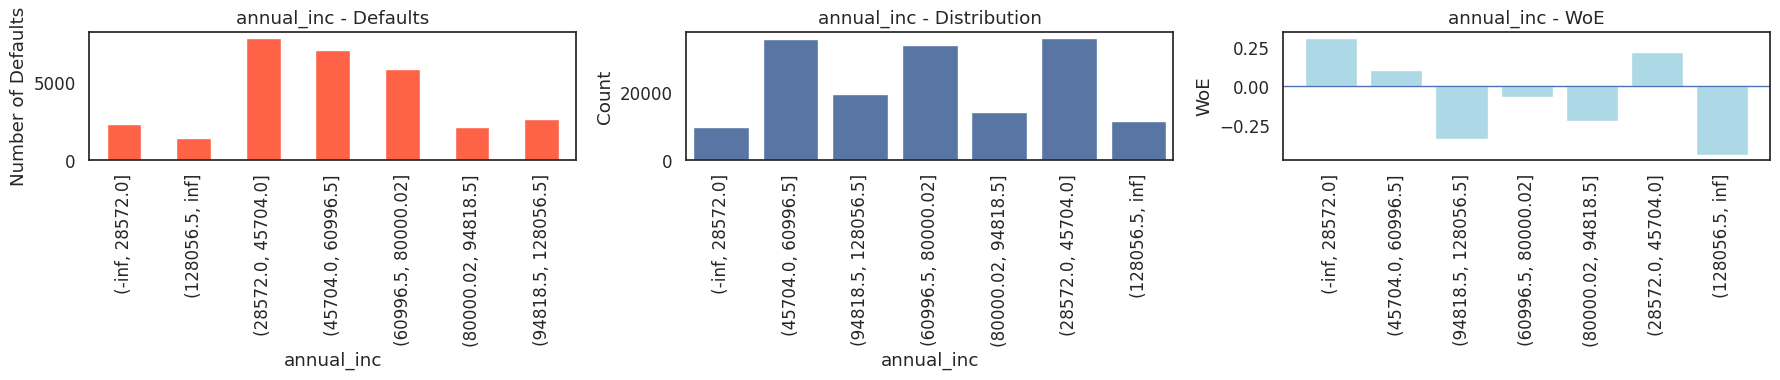

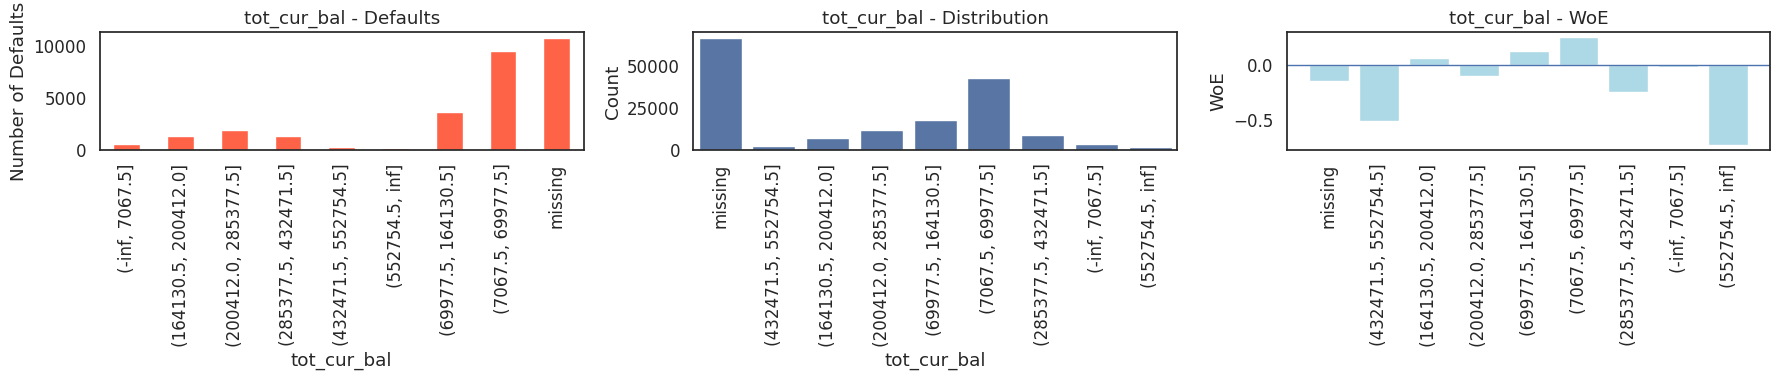

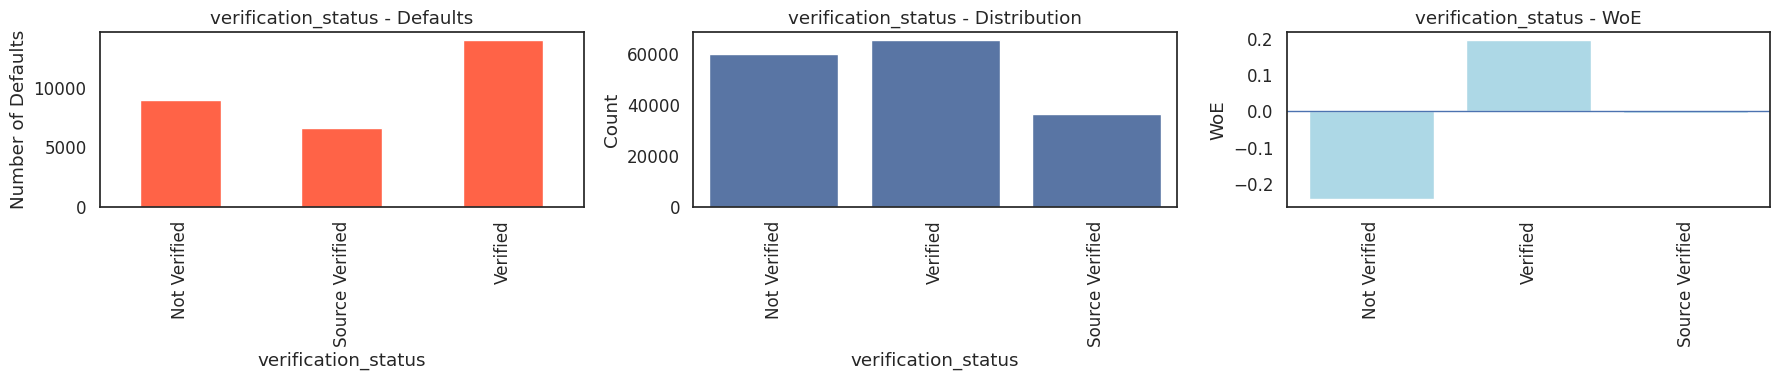

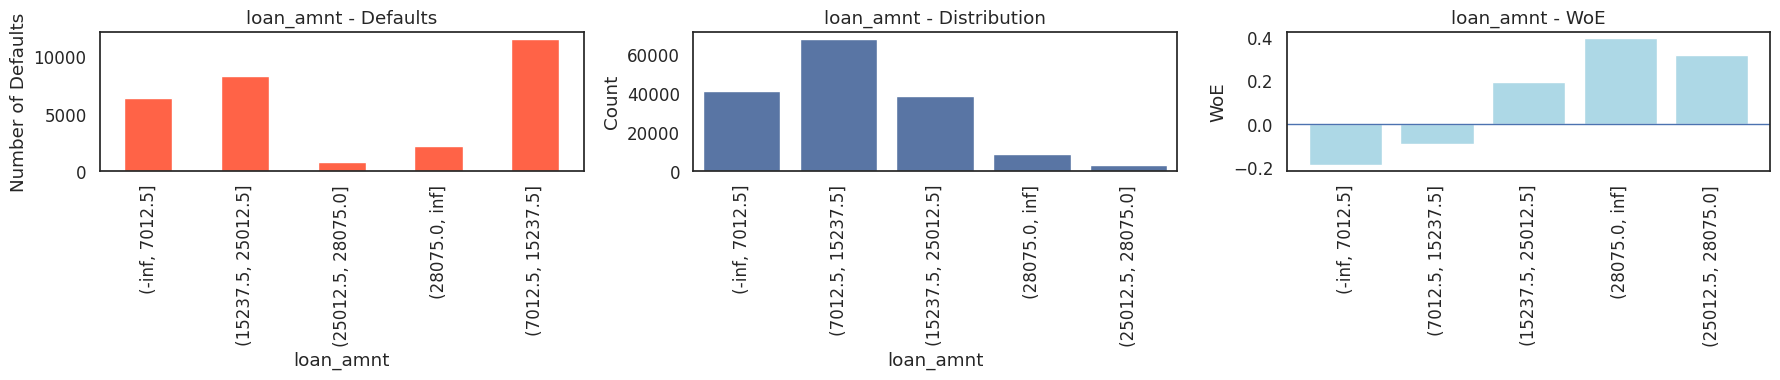

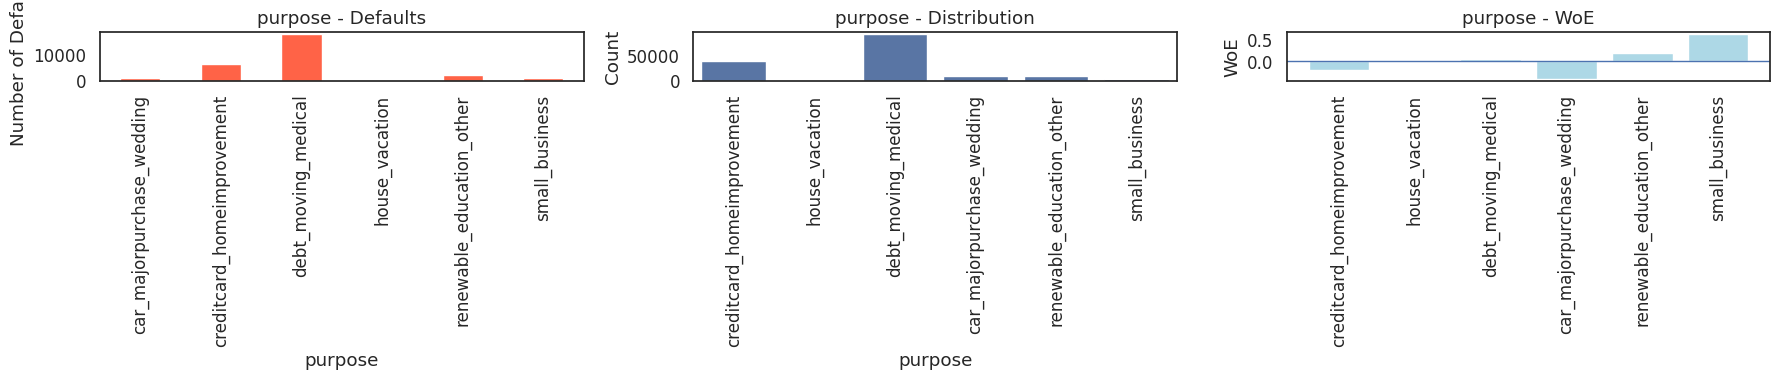

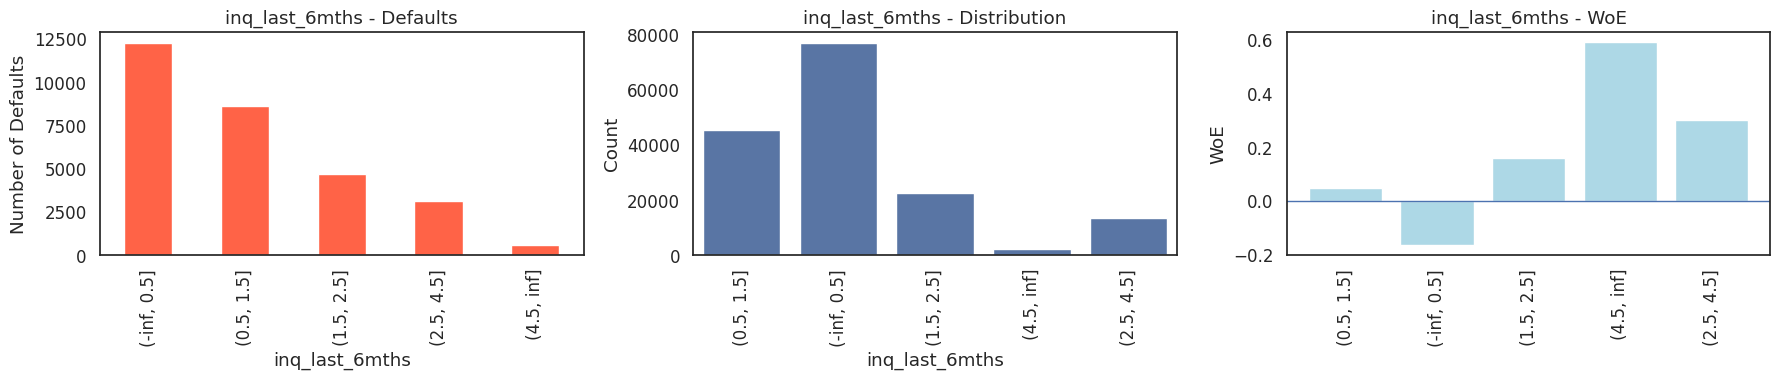

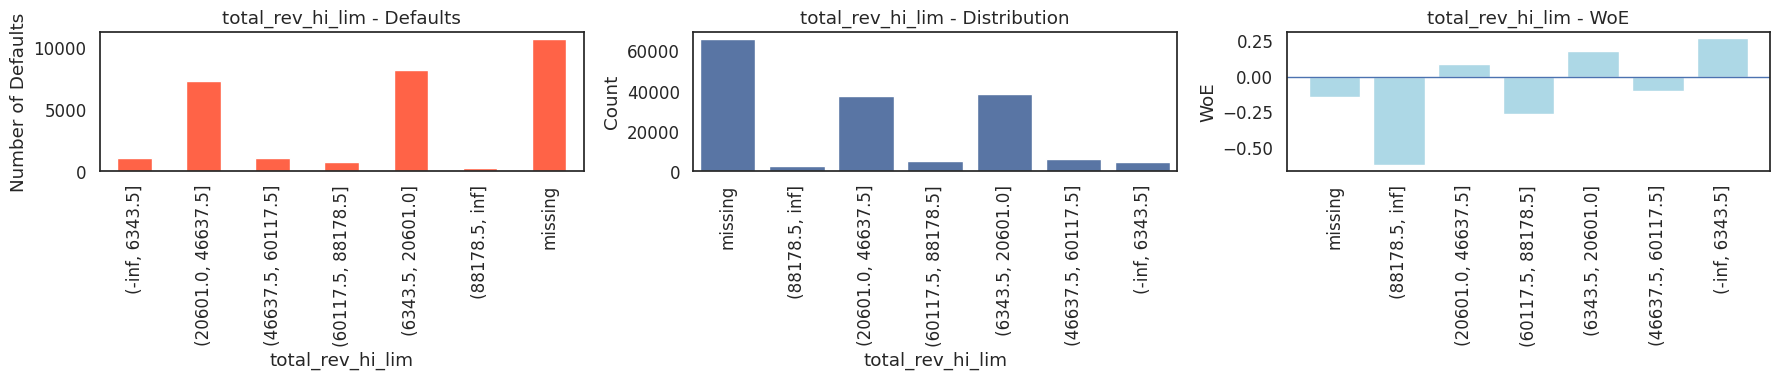

In [28]:
high_corr = ['funded_amnt','funded_amnt_inv','sub_grade','int_rate']
X_train_iv_2.drop(columns = high_corr, inplace = True)
X_test_iv_2.drop(columns = high_corr, inplace = True)
for col in X_train_iv_2.columns:
    plot_woe_bin(col, X_binned_2,X_woe_2)

Logistic regression was treated as the interpretable scorecard candidate, while XGBoost was used as a nonlinear challenger. Model selection was not based solely on the highest AUC. Because the objective includes construction of a transparent operational scorecard, interpretability, calibration, stability, and the magnitude of any performance improvement from the challenger were also considered.

In [29]:
import numpy as np
from sklearn.metrics import make_scorer

def ks_statistic(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    # Sort by predicted probability
    order = np.argsort(y_prob)
    y_true = y_true[order]

    # Cumulative distribution of non-defaults and defaults
    cum_good = np.cumsum(y_true == 0) / np.sum(y_true == 0)
    cum_bad = np.cumsum(y_true == 1) / np.sum(y_true == 1)

    # Maximum separation
    ks = np.max(np.abs(cum_bad - cum_good))

    return ks


ks_scorer = make_scorer(ks_statistic,response_method="predict_proba")

# Class imbalance ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Models
logistic = LogisticRegression(solver="liblinear",max_iter=5000,random_state=42)

xgb = XGBClassifier(eval_metric="logloss",random_state=42)

# Pipeline
pipeline = Pipeline([("model", logistic)])

# Hyperparameter grids
param_grid = [{"model": [logistic],"model__C": [100,10,1.0,0.1,0.01],"model__penalty": ["l1","l2"]},

   {"model": [xgb],"model__learning_rate": [0.01,0.05,0.1],"model__subsample": [0.8,1.0],"model__colsample_bytree": [0.8,1.0]}]

scoring = {"AUC": "roc_auc",
          "KS": ks_scorer,
          "AveragePrecision": "average_precision",
          "Brier": "neg_brier_score",
          "LogLoss": "neg_log_loss",
          "Accuracy": "accuracy",
          "Precision": "precision",
          "Recall": "recall",
          "F1": "f1"}

# Cross-validation
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# Randomized search
search = RandomizedSearchCV(pipeline,param_distributions=param_grid,n_iter=40,
    scoring=scoring,refit="AUC",cv=cv,n_jobs=-1,random_state=42,verbose=2,return_train_score=True)

# Fit
search.fit(X_train_iv_2, y_train)

result = pd.DataFrame(search.cv_results_)[["params", "mean_train_AUC","mean_test_AUC","std_test_AUC",
    "mean_train_KS","mean_test_KS","std_test_KS","mean_test_AveragePrecision","mean_test_Brier",
    "mean_test_LogLoss","mean_test_Accuracy","mean_test_Precision","mean_test_Recall","mean_test_F1"]].copy()

result["Brier"] = -result["mean_test_Brier"]
result["LogLoss"] = -result["mean_test_LogLoss"]
result["Gini"] = 2 * result["mean_test_AUC"] - 1
result["AUC_Gap"] = (result["mean_train_AUC"] -result["mean_test_AUC"])
result["KS_Gap"] = (result["mean_train_KS"] - result["mean_test_KS"])
# Remove the negative versions to avoid confusion
result = result.drop(columns=["mean_test_Brier","mean_test_LogLoss"])

# Sort according to the metric used for refit
result = (result.sort_values("mean_test_AUC", ascending=False).reset_index(drop=True))
display(result)

print("Best parameters:")
print(search.best_params_)

print("\nBest CV AUC:")
print(search.best_score_)

print("\nBest CV Gini:")
print(2 * search.best_score_ - 1)

print("\nBest model:")
print(search.best_estimator_.named_steps["model"])

Fitting 5 folds for each of 22 candidates, totalling 110 fits


,params,mean_train_AUC,mean_test_AUC,std_test_AUC,mean_train_KS,mean_test_KS,std_test_KS,mean_test_AveragePrecision,mean_test_Accuracy,mean_test_Precision,mean_test_Recall,mean_test_F1,Brier,LogLoss,Gini,AUC_Gap,KS_Gap
0,"{'model__subsample': 0.8, 'model__learning_rat...",0.717125,0.701609,0.003322,0.313905,0.293711,0.005450,0.342069,0.818057,0.526239,0.030870,0.058291,0.137118,0.435666,0.403219,0.015516,0.020194
1,"{'model__subsample': 1.0, 'model__learning_rat...",0.717184,0.701455,0.003424,0.313835,0.292245,0.005324,0.341811,0.818330,0.539419,0.031516,0.059522,0.137142,0.435759,0.402909,0.015730,0.021591
2,"{'model__subsample': 0.8, 'model__learning_rat...",0.718587,0.701423,0.003405,0.316201,0.295190,0.005439,0.342085,0.818324,0.533643,0.036173,0.067725,0.137126,0.435725,0.402846,0.017164,0.021011
3,"{'model__subsample': 0.8, 'model__learning_rat...",0.726276,0.701051,0.003120,0.326614,0.293343,0.005138,0.340732,0.818020,0.516944,0.042157,0.077939,0.137236,0.435959,0.402103,0.025224,0.033271
4,"{'model__subsample': 1.0, 'model__learning_rat...",0.718118,0.700843,0.003448,0.316258,0.293031,0.005014,0.341117,0.818355,0.536387,0.034915,0.065532,0.137214,0.435997,0.401686,0.017275,0.023226
5,"{'model__subsample': 1.0, 'model__learning_rat...",0.726133,0.700550,0.003203,0.327117,0.292052,0.004851,0.340537,0.818510,0.534919,0.042191,0.078197,0.137286,0.436177,0.401099,0.025583,0.035065
6,"{'model__subsample': 1.0, 'model__learning_rat...",0.727754,0.700138,0.003363,0.330035,0.292914,0.005492,0.339118,0.817970,0.515211,0.042599,0.078660,0.137393,0.436455,0.400276,0.027616,0.037121
7,"{'model__subsample': 0.8, 'model__learning_rat...",0.728921,0.700085,0.003298,0.330606,0.291765,0.006161,0.339507,0.818231,0.522510,0.045081,0.082993,0.137381,0.436386,0.400170,0.028836,0.038842
8,"{'model__penalty': 'l1', 'model__C': 0.1, 'mod...",0.699182,0.699018,0.003730,0.289568,0.290451,0.007039,0.338213,0.818187,0.526296,0.036887,0.068923,0.137479,0.436817,0.398037,0.000164,-0.000883
9,"{'model__penalty': 'l2', 'model__C': 0.1, 'mod...",0.699185,0.699014,0.003730,0.289644,0.290842,0.007202,0.338208,0.818169,0.525128,0.037397,0.069804,0.137480,0.436817,0.398027,0.000172,-0.001198


Best parameters:
{'model__subsample': 0.8, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8, 'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)}

Best CV AUC:
0.7016094131934005

Best CV Gini:
0.40321882638680107

Best model:
XGBClassifier(base_score=

Final model performance is evaluated separately on the development sample and the 2014 out-of-time test sample. AUC, Gini and KS evaluate discriminatory power; Brier Score and Log Loss evaluate probability quality; and Accuracy, Precision, Recall and F1 evaluate classification performance at the selected threshold. Similar train and out-of-time results indicate greater model stability.

In [30]:
result['params'][12]

{'model__penalty': 'l1',
 'model__C': 10,
 'model': LogisticRegression(max_iter=5000, random_state=42, solver='liblinear')}

In [31]:
logistic = LogisticRegression(solver="liblinear",max_iter=5000,random_state=42, penalty = 'l1', C = 0.1)
logistic.fit(X_train_iv_2, y_train)

y_train_pred = logistic.predict(X_train_iv_2)
y_train_proba = logistic.predict_proba(X_train_iv_2)[:, 1]

train_score = {
    "Accuracy": accuracy_score(y_train, y_train_pred),
    "Precision": precision_score(y_train, y_train_pred),
    "Recall": recall_score(y_train, y_train_pred),
    "F1": f1_score(y_train, y_train_pred),
    "AUC": roc_auc_score(y_train, y_train_proba),
    "Gini": 2 * roc_auc_score(y_train, y_train_proba) - 1,
    "Brier": brier_score_loss(y_train, y_train_proba),
    "LogLoss": log_loss(y_train, y_train_proba),
    "KS": ks_statistic(y_train, y_train_proba)}


# --------------------------------------------------
# TEST
# --------------------------------------------------

y_test_pred = logistic.predict(X_test_iv_2)
y_test_proba = logistic.predict_proba(X_test_iv_2)[:, 1]

test_score = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
    "AUC": roc_auc_score(y_test, y_test_proba),
    "Gini": 2 * roc_auc_score(y_test, y_test_proba) - 1,
    "Brier": brier_score_loss(y_test, y_test_proba),
    "LogLoss": log_loss(y_test, y_test_proba),
    "KS": ks_statistic(y_test, y_test_proba)}

score_comparison = pd.DataFrame({"Train": train_score, "Test": test_score})
score_comparison

,Train,Test
Accuracy,0.818150,0.791256
Precision,0.524085,0.543619
Recall,0.036989,0.051722
F1,0.069101,0.094457
AUC,0.699164,0.700243
Gini,0.398327,0.400485
Brier,0.137459,0.152101
LogLoss,0.436751,0.471957
KS,0.289238,0.292068


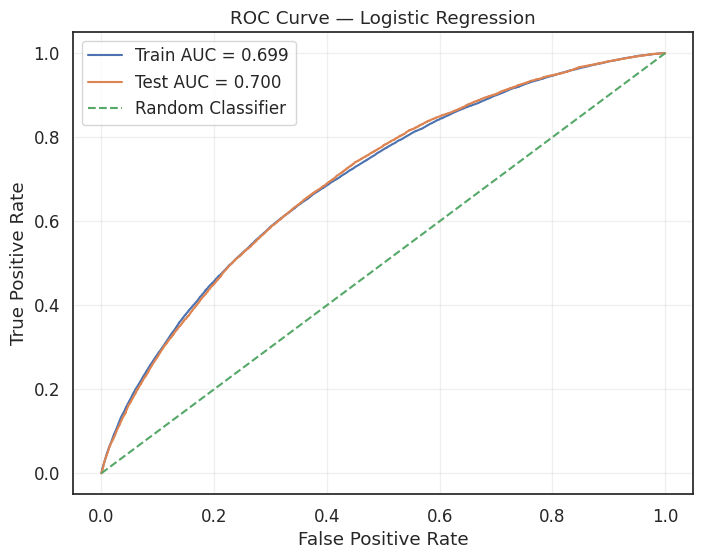

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score

# Train
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
auc_train = roc_auc_score(y_train, y_train_proba)

# Test
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train,tpr_train,label=f"Train AUC = {auc_train:.3f}")
plt.plot(fpr_test,tpr_test,label=f"Test AUC = {auc_test:.3f}")
# Random classifier
plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The ROC curve measures the trade-off between true-positive and false-positive rates across all classification thresholds. The closer the curve is to the upper-left corner, the stronger the discriminatory performance. Similar train and test ROC curves indicate that the model's ranking ability is relatively stable out of sample.

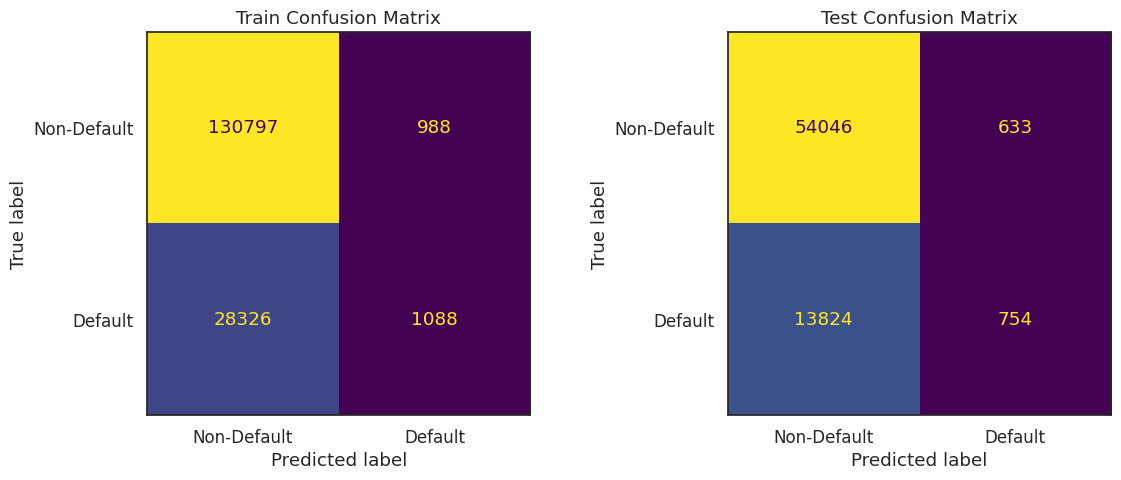

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Train
cm_train = confusion_matrix(y_train, y_train_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_train,display_labels=["Non-Default", "Default"]).plot(ax=axes[0],values_format="d",colorbar=False)
axes[0].set_title("Train Confusion Matrix")

# Test
cm_test = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_test,display_labels=["Non-Default", "Default"]).plot(ax=axes[1],values_format="d",colorbar=False)
axes[1].set_title("Test Confusion Matrix")
plt.tight_layout()
plt.show()

The confusion matrix evaluates classifications at a specific PD cutoff. A false negative corresponds to an actual defaulter classified as non-default, while a false positive corresponds to a non-default borrower classified as default. Because these errors have different economic costs, the default 0.50 probability threshold should not automatically be treated as the optimal lending cutoff.

#### **Gain Table**

In [34]:
def gains_table(y_true, y_proba, n_bins=10):

    gains = pd.DataFrame({"Actual": np.asarray(y_true),"PD": np.asarray(y_proba)})
    # Highest predicted default risk first
    gains = gains.sort_values("PD",ascending=False).reset_index(drop=True)
    # Divide observations into approximately equal-sized deciles
    gains["Decile"] = pd.qcut(gains.index, q=n_bins,labels=range(1, n_bins + 1))
    table = (gains.groupby("Decile", observed=True).agg(Count=("Actual", "size"),Defaults=("Actual", "sum"), Average_PD=("PD", "mean")))
    table["Non_Defaults"] = (table["Count"] - table["Defaults"])
    table["Default_Rate"] = (table["Defaults"] / table["Count"])
    table["Population_%"] = (table["Count"] / table["Count"].sum())
    table["Cumulative_Population_%"] = (table["Population_%"].cumsum())
    table["Cumulative_Defaults"] = (table["Defaults"].cumsum())
    table["Cumulative_Gain"] = (table["Cumulative_Defaults"]/ table["Defaults"].sum())
    table["Lift"] = (table["Cumulative_Gain"]/ table["Cumulative_Population_%"])
    return table

train_gains = gains_table(y_train,y_train_proba)
train_gains

,Count,Defaults,Average_PD,Non_Defaults,Default_Rate,Population_%,Cumulative_Population_%,Cumulative_Defaults,Cumulative_Gain,Lift
Decile,,,,,,,,,,
1,16120,6630,0.416845,9490,0.411290,0.100001,0.100001,6630,0.225403,2.254015
2,16120,4877,0.295524,11243,0.302543,0.100001,0.200001,11507,0.391208,1.956029
3,16120,3912,0.240591,12208,0.242680,0.100001,0.300002,15419,0.524206,1.747343
4,16120,3291,0.202596,12829,0.204156,0.100001,0.400002,18710,0.636092,1.590219
5,16120,2708,0.173150,13412,0.167990,0.100001,0.500003,21418,0.728157,1.456304
6,16119,2447,0.147972,13672,0.151808,0.099994,0.599998,23865,0.811348,1.352253
7,16120,1952,0.124137,14168,0.121092,0.100001,0.699998,25817,0.877711,1.253877
8,16120,1677,0.099999,14443,0.104032,0.100001,0.799999,27494,0.934725,1.168408
9,16120,1195,0.076130,14925,0.074132,0.100001,0.899999,28689,0.975352,1.083725


In [35]:
test_gains = gains_table(y_test,y_test_proba)
test_gains

,Count,Defaults,Average_PD,Non_Defaults,Default_Rate,Population_%,Cumulative_Population_%,Cumulative_Defaults,Cumulative_Gain,Lift
Decile,,,,,,,,,,
1,6926,3103,0.452612,3823,0.448022,0.100004,0.100004,3103,0.212855,2.128458
2,6926,2350,0.340961,4576,0.339301,0.100004,0.200009,5453,0.374057,1.870203
3,6925,2045,0.281813,4880,0.295307,0.099990,0.299999,7498,0.514337,1.714464
4,6926,1672,0.239693,5254,0.241409,0.100004,0.400003,9170,0.629030,1.572564
5,6926,1459,0.204761,5467,0.210656,0.100004,0.500007,10629,0.729112,1.458204
6,6925,1233,0.174266,5692,0.178051,0.099990,0.599997,11862,0.813692,1.356160
7,6926,955,0.146065,5971,0.137886,0.100004,0.700001,12817,0.879202,1.256000
8,6925,813,0.116889,6112,0.117401,0.099990,0.799991,13630,0.934971,1.168726
9,6926,585,0.087292,6341,0.084464,0.100004,0.899996,14215,0.975099,1.083449


The gains table evaluates how effectively the model concentrates defaults in the highest-risk segments. Borrowers are ranked from highest to lowest predicted PD and divided into deciles. Cumulative gain represents the percentage of all defaults captured after examining a given proportion of the portfolio, while lift compares this concentration with random selection.

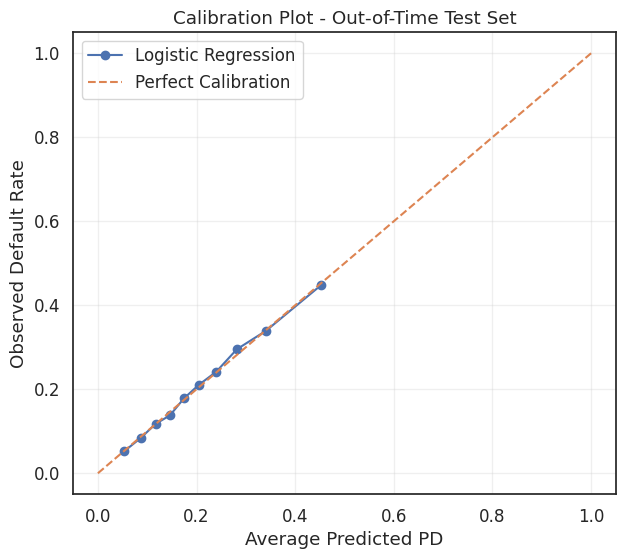

In [36]:
plt.figure(figsize=(7, 6))

plt.plot(test_gains["Average_PD"],test_gains["Default_Rate"],marker="o",label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--",label="Perfect Calibration")

plt.xlabel("Average Predicted PD")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Plot - Out-of-Time Test Set")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

The out-of-time calibration curve lies close to the 45-degree perfect-calibration line over the observed probability range. This indicates that borrowers assigned, for example, a 20% average predicted PD experience an observed default rate close to 20%. The model therefore demonstrates not only useful ranking ability but also strong alignment between predicted and realized default frequencies on the test sample.

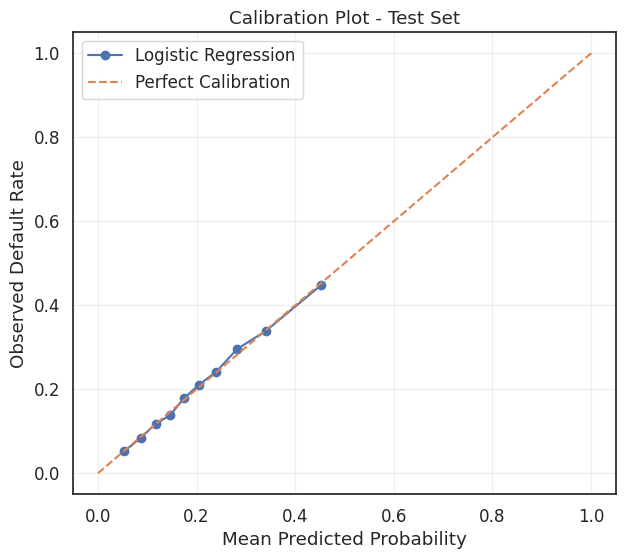

In [37]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test,y_test_proba,n_bins=10, strategy="quantile")
plt.figure(figsize=(7, 6))
plt.plot(prob_pred,prob_true,marker="o",label="Logistic Regression")
plt.plot([0, 1],[0, 1],linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Plot - Test Set")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [38]:
pd.DataFrame({"Mean_Predicted_PD": prob_pred,"Observed_Default_Rate": prob_true})

,Mean_Predicted_PD,Observed_Default_Rate
0,0.053425,0.052411
1,0.087292,0.084464
2,0.116889,0.117401
3,0.146065,0.137886
4,0.174269,0.178025
5,0.204763,0.210686
6,0.239693,0.241409
7,0.281813,0.295307
8,0.340961,0.339301
9,0.452612,0.448022


In [39]:
def table(col):
    df_bin = X_binned_2[[col]].copy()
    df_bin["woe"] = X_woe_2[col].values
    df_bin = (df_bin[[col, "woe"]].drop_duplicates().reset_index(drop=True))
    df_bin["column"] = col
    df_bin = df_bin.rename(columns={col: "bin"})
    return df_bin

coef_data = pd.DataFrame({"column": X_train_iv_2.columns})
coef_data["coefficient"] = logistic.coef_[0]
coef_data["intercept"] = logistic.intercept_[0]
bin_woe = pd.concat([table(col) for col in X_train_iv_2.columns],ignore_index=True)
final_data = pd.merge(bin_woe,coef_data,on="column")

The logistic PD model is converted to a credit score using a linear transformation of log-odds. A base score of 1000 is assigned to Bad:Good odds of 1:10, corresponding to a PD of approximately 9.09%. The PDO is set to 200, meaning that every doubling of Bad:Good odds reduces the credit score by 200 points.

- Base Points = 1000
- Base Odds = 10:1 for 10 target being 1 to 1 target being 0
- Points to Double Odds (PDO) = 200



In [40]:
base_score = 1000
base_odds = 0.10       # Bad:Good = target 1 : target 0
pdo = 200

factor = pdo / np.log(2)
offset = base_score + factor * np.log(base_odds)
n = len(X_train_iv_2.columns)

final_data['score'] = (offset / n  - factor * (final_data['woe'] * final_data['coefficient'] + final_data['intercept'] / n))
final_data.sort_values(by= 'score')

,bin,woe,column,coefficient,intercept,score
2,F_G,1.108084,grade,0.656046,-1.501284,-139.864214
0,E,0.829500,grade,0.656046,-1.501284,-87.129784
54,small_business,0.619753,purpose,0.690066,-1.501284,-53.509272
25,"(-inf, 28572.0]",0.310533,annual_inc,1.362150,-1.501284,-52.159666
7,"(-inf, 0.5]",0.736410,term,0.573513,-1.501284,-51.971563
...,...,...,...,...,...,...
40,"(552754.5, inf]",-0.722178,tot_cur_bal,0.393184,-1.501284,151.820618
29,"(80000.02, 94818.5]",-0.223953,annual_inc,1.362150,-1.501284,157.911410
27,"(94818.5, 128056.5]",-0.337889,annual_inc,1.362150,-1.501284,202.692110
31,"(128056.5, inf]",-0.438123,annual_inc,1.362150,-1.501284,242.087492


The score transformation was validated by reversing the score equation and reconstructing PD. The reconstructed probabilities are compared with LogisticRegression.predict_proba(). A difference close to numerical floating-point precision confirms that the scorecard is mathematically equivalent to the fitted logistic model.

In [41]:
train_logit = logistic.decision_function(X_train_iv_2)
train_score_direct = (offset- factor * train_logit)
test_logit = logistic.decision_function(X_test_iv_2)
test_score_direct = (offset- factor * test_logit)

from scipy.special import expit
train_pd_from_score = expit((offset - train_score_direct) / factor)
test_pd_from_score = expit((offset - test_score_direct) / factor)
y_train_proba = logistic.predict_proba(X_train_iv_2)[:, 1]
y_test_proba = logistic.predict_proba(X_test_iv_2)[:, 1]

print("Maximum Train PD Difference:", np.max(np.abs(y_train_proba - train_pd_from_score)))
print("Maximum Test PD Difference:", np.max( np.abs(y_test_proba - test_pd_from_score)))

Maximum Train PD Difference: 1.1102230246251565e-16
Maximum Test PD Difference: 1.6653345369377348e-16


In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
!jupyter nbconvert \
    --to html \
    "/content/drive/MyDrive/credit risk-lending clubb/credit risk.ipynb" \
    --output "/content/credit risk.html"

[NbConvertApp] Converting notebook /content/drive/MyDrive/credit risk-lending clubb/credit risk.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 33 image(s).
[NbConvertApp] Writing 3347828 bytes to /content/credit risk.html


In [44]:
from google.colab import files
files.download('/content/credit risk.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>